In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import sys
import re
import os
import glob
from matplotlib import rcParams
import random
from matplotlib.colors import LogNorm

%matplotlib inline


rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

In [26]:
path = "/data/elena/data/Gd/p_350"
filename = os.path.join(path, "WCTE_merged_production_R2379.root")  #already processed data

with uproot.open(filename) as file:
    for key in file.keys():
        print(f"Tree: {key}")

match = re.search(r'R(\d{4})\.root', filename)
if match:
    run_number = match.group(1)
else:
    run_number = "Unknown"

print(f"Detected Run Number: {run_number}")

Tree: WCTEReadoutWindows;1499
Tree: WCTEReadoutWindows;1498
Tree: vme_analysis_scalar_results;1
Tree: vme_analysis_run_info;1
Tree: DataQualityMetrics;1
Tree: Configuration;1
Detected Run Number: 2379


In [27]:
with uproot.open(filename) as f:

    print("Trees:\n")

    for key in f.keys():
        tree = f[key]

        # Skip objects that are not TTrees
        if not isinstance(tree, uproot.behaviors.TTree.TTree):
            continue

        print(f"\n=== {key} ===")

        for branch in tree.keys():
            print(branch)

Trees:


=== WCTEReadoutWindows;1499 ===
window_time
start_counter
run_id
sub_run_id
spill_counter
event_number
readout_number
hit_pmt_calibrated_times
hit_pmt_charges
hit_mpmt_slot_ids
hit_pmt_position_ids
hit_pmt_readout_mask
window_data_quality_mask
trigger_board_hit_card_ids
trigger_board_hit_channel_ids
trigger_board_hit_charges
trigger_board_hit_times
trigger_board_waveform_card_ids
trigger_board_waveform_channel_ids
trigger_board_waveform_times
trigger_board_waveforms
vme_t0_time
vme_t1_time
vme_t4_time
vme_t0_time_second_hit
vme_t1_time_second_hit
vme_t4_time_second_hit
vme_time_t0_0
vme_time_t0_1
vme_time_t0_2
vme_time_t0_3
vme_time_t1_0
vme_time_t1_1
vme_time_t1_2
vme_time_t1_3
vme_time_t4_0
vme_time_t4_1
vme_t5_time
vme_t4_l_time
vme_t4_r_time
vme_t4_l_second_hit
vme_t4_r_second_hit
vme_act0_l_charge
vme_act1_l_charge
vme_act2_l_charge
vme_act3_l_charge
vme_act4_l_charge
vme_act5_l_charge
vme_act0_r_charge
vme_act1_r_charge
vme_act2_r_charge
vme_act3_r_charge
vme_act4_r_char

In [29]:
# ================================================================
# Branches needed for PID, event quality, and beam coincidence
# ================================================================

window_branches = [

    # ------------------------------------------------------------
    # Event / window quality
    # ------------------------------------------------------------
    "window_data_quality_mask",
    "vme_evt_quality_bitmask",
    "vme_digi_issues_bitmask",

    # ------------------------------------------------------------
    # T5 information
    # ------------------------------------------------------------
    "T5_HasValidHit",
    "T5_HasMultipleScintillatorsHit",
    "T5_HasOutOfTimeWindow",
    "T5_HasInTimeWindow",
    "T5_particle_nr",

    "T5_hit_is_in_bounds",
    "T5_hit_pos_x",
    "T5_hit_pos_y",
    "T5_hit_time",

    "T5_secondary_hit_is_in_bounds",
    "T5_secondary_hit_pos_x",
    "T5_secondary_hit_pos_y",
    "T5_secondary_hit_time",

    # ------------------------------------------------------------
    # ACT information
    # ------------------------------------------------------------
    "vme_act_eveto",
    "vme_act_tagger",

    # ------------------------------------------------------------
    # TOF
    # ------------------------------------------------------------
    "vme_tof_corr",

    # ------------------------------------------------------------
    # T0 / T1 / T4 timing information
    # ------------------------------------------------------------
    "vme_t0_time",
    "vme_t1_time",
    "vme_t4_time",

    # Second-hit information
    "vme_t0_time_second_hit",
    "vme_t1_time_second_hit",
    "vme_t4_time_second_hit",

    # Individual T0 channels
    "vme_time_t0_0",
    "vme_time_t0_1",
    "vme_time_t0_2",
    "vme_time_t0_3",

    # Individual T1 channels
    "vme_time_t1_0",
    "vme_time_t1_1",
    "vme_time_t1_2",
    "vme_time_t1_3",

    # Individual T4 channels
    "vme_time_t4_0",
    "vme_time_t4_1",

    # T4 left/right information
    "vme_t4_l_time",
    "vme_t4_r_time",
    "vme_t4_l_second_hit",
    "vme_t4_r_second_hit",

    # ------------------------------------------------------------
    # T0 / T1 / T4 charge information
    # ------------------------------------------------------------

    # T0
    "vme_charge_t0_0",
    "vme_charge_t0_1",
    "vme_charge_t0_2",
    "vme_charge_t0_3",

    # T1
    "vme_charge_t1_0",
    "vme_charge_t1_1",
    "vme_charge_t1_2",
    "vme_charge_t1_3",

    # T4
    "vme_charge_t4_0",
    "vme_charge_t4_1",

    # T4 left/right charge
    "vme_act0_l_charge",
    "vme_act1_l_charge",
    "vme_act2_l_charge",
    "vme_act3_l_charge",
    "vme_act4_l_charge",
    "vme_act5_l_charge",

    "vme_act0_r_charge",
    "vme_act1_r_charge",
    "vme_act2_r_charge",
    "vme_act3_r_charge",
    "vme_act4_r_charge",
    "vme_act5_r_charge",

    # ------------------------------------------------------------
    # Other VME timing information
    # ------------------------------------------------------------
    "vme_t5_time",
    "vme_ref0_time",
    "vme_ref1_time",

    # ------------------------------------------------------------
    # Event identifiers
    # ------------------------------------------------------------
    "window_time",
    "start_counter",
    "run_id",
    "sub_run_id",
    "spill_counter",
    "event_number",
    "readout_number",

    # ------------------------------------------------------------
    # WCTE PMT information
    # ------------------------------------------------------------
    "hit_mpmt_slot_ids",
    "hit_pmt_position_ids",
    "hit_pmt_charges",
    "hit_pmt_calibrated_times",
]


# ================================================================
# Scalar branches
# ================================================================

scalar_branches = [

    "act_eveto_cut",
    "act_tagger_cut",

    "tof_mean_pion",

    "n_pions",
    "momentum_mean_pion",
]


# ================================================================
# Load all events
# ================================================================

N = 100000000   # effectively all events

with uproot.open(filename) as file:

    tree_windows = file["WCTEReadoutWindows"]
    tree_scalars = file["vme_analysis_scalar_results"]

    # --- AQUÍ ESTÁ EL CAMBIO CLAVE PARA EL RUN 2379 ---
    available_keys = tree_windows.keys()
    
    # Selecciona solo las ramas que realmente existen en este archivo concreto
    filtered_window_branches = [b for b in window_branches if b in available_keys]
    
    # Para las ramas que faltan (como las T5 antiguas en el Run 2379), 
    # podemos añadir un aviso o dejar que el código cargue las disponibles:
    missing_branches = [b for b in window_branches if b not in available_keys]
    if missing_branches:
        print(f"[Aviso] Omitiendo {len(missing_branches)} ramas ausentes en este run (ej. Run 2379): {missing_branches[:3]}...")

    arrays_windows = tree_windows.arrays(
        filtered_window_branches,
        entry_start=0,
        entry_stop=N,
        library="ak"
    )

    arrays_scalars = tree_scalars.arrays(
        scalar_branches,
        entry_start=0,
        entry_stop=N,
        library="ak"
    )


# ================================================================
# Check what was loaded
# ================================================================

print("WCTEReadoutWindows data:")
for field in arrays_windows.fields:
    print(f"  - {field}")

print("\nvme_analysis_scalar_results data:")
for field in arrays_scalars.fields:
    print(f"  - {field}")

print(f"\nLoaded readout windows: {len(arrays_windows.window_time)}")

[Aviso] Omitiendo 13 ramas ausentes en este run (ej. Run 2379): ['T5_HasValidHit', 'T5_HasMultipleScintillatorsHit', 'T5_HasOutOfTimeWindow']...


KeyInFileError: not found: 'momentum_mean_pion'
in file /data/elena/data/Gd/p_350/WCTE_merged_production_R2379.root
in object /vme_analysis_scalar_results;1

In [6]:
# ================================================================
# CHECK HOW T0, T1 AND T4 ENCODE A HIT / NO HIT
# ================================================================

for name in [
    "vme_t0_time",
    "vme_t1_time",
    "vme_t4_time"
]:

    x = arrays_windows[name]

    print("\n================================================")
    print(name)
    print("================================================")

    print("Awkward type:")
    print(ak.type(x))

    print("\nFirst 20 values:")
    print(ak.to_list(x[:20]))

    print("\nNumber of None:")
    print(ak.sum(ak.is_none(x)))

    # Convert to NumPy if possible
    x_np = ak.to_numpy(x)

    print("\nNumPy dtype:")
    print(x_np.dtype)

    print("Number of NaN:")
    if np.issubdtype(x_np.dtype, np.floating):
        print(np.sum(np.isnan(x_np)))

    print("\nMinimum:")
    print(np.nanmin(x_np))

    print("Maximum:")
    print(np.nanmax(x_np))

    print("\nSome unique values:")
    print(np.unique(x_np)[:30])


vme_t0_time
Awkward type:
873864 * float64

First 20 values:
[-214.85000610351562, -210.57499313354492, -209.36249542236328, -204.46250534057617, -206.97500228881836, -198.9124984741211, -198.59375381469727, -199.36249542236328, -199.0687599182129, -203.00624084472656, -212.71250534057617, -208.6125030517578, -210.4187469482422, -198.61248779296875, -203.95000076293945, -212.01874542236328, -210.29999542236328, -202.2375030517578, -199.72499084472656, -200.32500076293945]

Number of None:
0

NumPy dtype:
float64
Number of NaN:
834985

Minimum:
-251.49374389648438
Maximum:
246.70624542236328

Some unique values:
[-251.4937439  -247.00000381 -246.39373779 -245.01249313 -244.53749466
 -236.75625229 -236.70624924 -235.57500839 -234.07499313 -232.48749542
 -231.43749237 -229.74999237 -228.84375381 -226.53749466 -223.93750381
 -223.92499924 -218.88749695 -218.73125839 -218.72499084 -218.7124939
 -218.70624924 -218.70000839 -218.59374237 -218.58750153 -218.57500076
 -218.5562439  -218.549999

In [7]:
# ================================================================
# T0 / T1 / T4 HIT DIAGNOSTICS
# ================================================================

T0_hit = ~np.isnan(ak.to_numpy(arrays_windows["vme_t0_time"]))
T1_hit = ~np.isnan(ak.to_numpy(arrays_windows["vme_t1_time"]))
T4_hit = ~np.isnan(ak.to_numpy(arrays_windows["vme_t4_time"]))

print("================================================")
print("NUMBER OF EVENTS WITH A VALID HIT")
print("================================================")

print(f"T0 hits: {np.sum(T0_hit)}")
print(f"T1 hits: {np.sum(T1_hit)}")
print(f"T4 hits: {np.sum(T4_hit)}")

print("\n================================================")
print("COINCIDENCES")
print("================================================")

print(f"T0 & T1:       {np.sum(T0_hit & T1_hit)}")
print(f"T0 & T4:       {np.sum(T0_hit & T4_hit)}")
print(f"T1 & T4:       {np.sum(T1_hit & T4_hit)}")
print(f"T0 & T1 & T4:  {np.sum(T0_hit & T1_hit & T4_hit)}")

NUMBER OF EVENTS WITH A VALID HIT
T0 hits: 38879
T1 hits: 38856
T4 hits: 38462

COINCIDENCES
T0 & T1:       38853
T0 & T4:       38105
T1 & T4:       38085
T0 & T1 & T4:  38082


In [8]:
# ================================================================
# GOOD EVENTS + T0/T1/T4/T5 BEAM COINCIDENCE
# ================================================================

# ------------------------------------------------
# 1. DATA QUALITY
# ------------------------------------------------

data_quality = arrays_windows["window_data_quality_mask"] == 0
evt_quality  = arrays_windows["vme_evt_quality_bitmask"] == 0
digi_issues  = arrays_windows["vme_digi_issues_bitmask"] == 0


# ------------------------------------------------
# 2. T5 REQUIREMENTS
# ------------------------------------------------

valid_hit   = arrays_windows["T5_HasValidHit"] == True
mult_scint  = arrays_windows["T5_HasMultipleScintillatorsHit"] == False
out_of_time = arrays_windows["T5_HasOutOfTimeWindow"] == False
in_time     = arrays_windows["T5_HasInTimeWindow"] == True
particle_nr = arrays_windows["T5_particle_nr"] == 1


# ------------------------------------------------
# 3. T0 / T1 / T4 COINCIDENCE
# ------------------------------------------------

# A valid timing value means that the detector registered a hit.
# NaN corresponds to no reconstructed hit.

T0_hit = ~np.isnan(ak.to_numpy(arrays_windows["vme_t0_time"]))
T1_hit = ~np.isnan(ak.to_numpy(arrays_windows["vme_t1_time"]))
T4_hit = ~np.isnan(ak.to_numpy(arrays_windows["vme_t4_time"]))


# ------------------------------------------------
# 4. FINAL EVENT SELECTION
# ------------------------------------------------

good_mask = (
    data_quality
    & evt_quality
    & digi_issues

    # T5
    & valid_hit
    & mult_scint
    & out_of_time
    & in_time
    & particle_nr

    # Beam coincidence
    & T0_hit
    & T1_hit
    & T4_hit
)


# ------------------------------------------------
# 5. APPLY SELECTION
# ------------------------------------------------

filtered_windows = arrays_windows[good_mask]


# ------------------------------------------------
# 6. STATISTICS
# ------------------------------------------------

total_events = len(arrays_windows)
n_filtered_events = len(filtered_windows)
fraction = (n_filtered_events / total_events) * 100


print(f"Run number: {run_number}")
print(f"Total number of readout windows loaded: {total_events}")
print(
    f"Filtered readout windows "
    f"(Quality + T0/T1/T4/T5): {n_filtered_events}"
)
print(f"Fraction: {fraction:.3f}%")

Run number: 2408
Total number of readout windows loaded: 873864
Filtered readout windows (Quality + T0/T1/T4/T5): 2562
Fraction: 0.293%


Run number: 2408
Quality + T0/T1/T4/T5 events: 2562

Electron separation:
  Electron candidates rejected: 1918
  Non-electron events retained: 644
  Electron rejection fraction: 74.863%


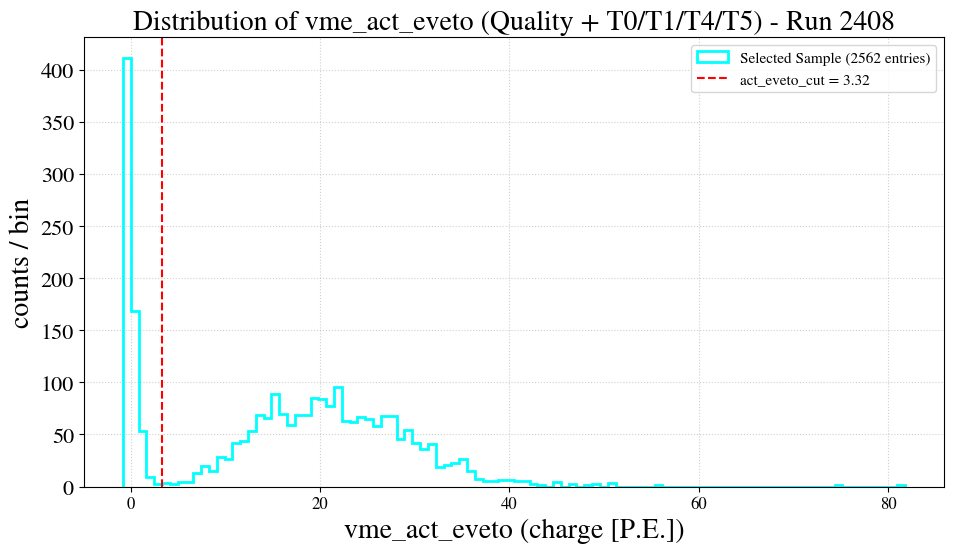


Muon / pion separation:
  Pion candidates: 81
  Muon candidates: 563
  Pion fraction among non-electrons: 12.578%
  Muon fraction among non-electrons: 87.422%


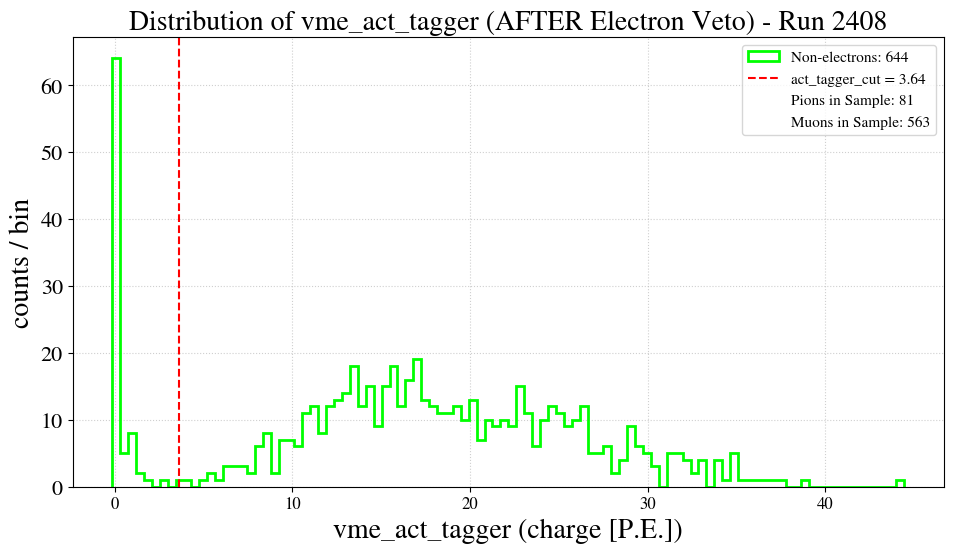

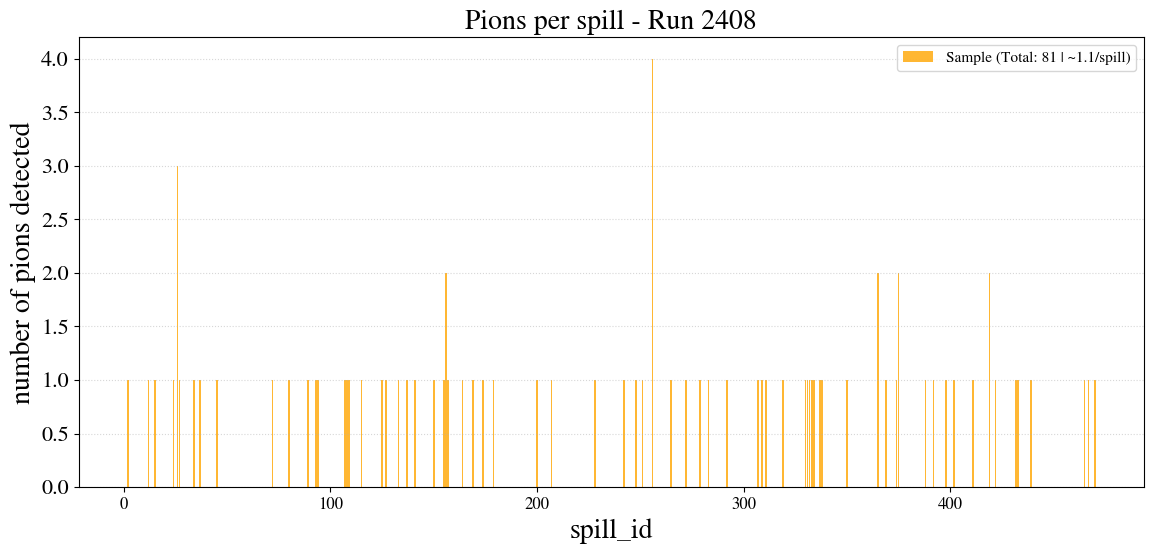

In [9]:
# ================================================================
# PID PLOTS AFTER QUALITY + T0/T1/T4/T5 SELECTION
# ================================================================

# filtered_windows already contains:
#   - Data quality cuts
#   - Event quality cuts
#   - Digital issue cuts
#   - T5 requirements
#   - T0 coincidence
#   - T1 coincidence
#   - T4 coincidence
#
# PID is performed in two steps:
#   1. Electron rejection using vme_act_eveto
#   2. Muon/pion separation using vme_act_tagger


# -----------------------------------------------------------------------------
# 1. CUT VALUES
# -----------------------------------------------------------------------------

eveto_cut_val = ak.to_numpy(
    arrays_scalars["act_eveto_cut"]
)[0]

tagger_cut_val = ak.to_numpy(
    arrays_scalars["act_tagger_cut"]
)[0]


# -----------------------------------------------------------------------------
# 2. DATA FROM THE SELECTED SAMPLE
# -----------------------------------------------------------------------------

act_eveto = ak.to_numpy(
    filtered_windows["vme_act_eveto"]
)

act_tagger = ak.to_numpy(
    filtered_windows["vme_act_tagger"]
)

spill_counter = ak.to_numpy(
    filtered_windows["spill_counter"]
)

total_selected = len(filtered_windows)

print(f"Run number: {run_number}")
print(f"Quality + T0/T1/T4/T5 events: {total_selected}")


# -----------------------------------------------------------------------------
# 3. STEP 1 — ELECTRON REJECTION
# -----------------------------------------------------------------------------

mask_no_e = act_eveto < eveto_cut_val

n_electrons = np.sum(~mask_no_e)
n_non_electrons = np.sum(mask_no_e)

print()
print("Electron separation:")
print(f"  Electron candidates rejected: {n_electrons}")
print(f"  Non-electron events retained: {n_non_electrons}")
print(
    f"  Electron rejection fraction: "
    f"{100 * n_electrons / total_selected:.3f}%"
)


# -----------------------------------------------------------------------------
# Plot 1: Distribution of vme_act_eveto
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    act_eveto,
    bins=100,
    histtype="step",
    linewidth=2,
    color="cyan",
    label=f"Selected Sample ({total_selected} entries)"
)

plt.axvline(
    x=eveto_cut_val,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"act_eveto_cut = {eveto_cut_val:.2f}"
)

plt.title(
    f"Distribution of vme_act_eveto "
    f"(Quality + T0/T1/T4/T5) - Run {run_number}"
)

plt.xlabel("vme_act_eveto (charge [P.E.])")
plt.ylabel("counts / bin")

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 4. APPLY ELECTRON VETO
# -----------------------------------------------------------------------------

tagger_clean = act_tagger[mask_no_e]
spills_clean = spill_counter[mask_no_e]


# -----------------------------------------------------------------------------
# 5. STEP 2 — MUON / PION SEPARATION
# -----------------------------------------------------------------------------

pions_mask = tagger_clean < tagger_cut_val
muons_mask = ~pions_mask

n_pions = np.sum(pions_mask)
n_muons = np.sum(muons_mask)

print()
print("Muon / pion separation:")
print(f"  Pion candidates: {n_pions}")
print(f"  Muon candidates: {n_muons}")

print(
    f"  Pion fraction among non-electrons: "
    f"{100 * n_pions / n_non_electrons:.3f}%"
)

print(
    f"  Muon fraction among non-electrons: "
    f"{100 * n_muons / n_non_electrons:.3f}%"
)


# -----------------------------------------------------------------------------
# Plot 2: Distribution of vme_act_tagger
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    tagger_clean,
    bins=100,
    histtype="step",
    linewidth=2,
    color="lime",
    label=f"Non-electrons: {len(tagger_clean)}"
)

plt.axvline(
    x=tagger_cut_val,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"act_tagger_cut = {tagger_cut_val:.2f}"
)

plt.title(
    f"Distribution of vme_act_tagger "
    f"(AFTER Electron Veto) - Run {run_number}"
)

plt.xlabel("vme_act_tagger (charge [P.E.])")
plt.ylabel("counts / bin")

plt.grid(True, linestyle=":", alpha=0.6)

plt.plot(
    [],
    [],
    " ",
    label=f"Pions in Sample: {n_pions}"
)

plt.plot(
    [],
    [],
    " ",
    label=f"Muons in Sample: {n_muons}"
)

plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 6. SELECT PIONS
# -----------------------------------------------------------------------------

spills_pions = spills_clean[pions_mask]


# -----------------------------------------------------------------------------
# Plot 3: Pions per Spill
# -----------------------------------------------------------------------------

df_pions = pd.DataFrame({
    "spill_counter": spills_pions
})

pions_per_spill = (
    df_pions
    .groupby("spill_counter")
    .size()
    .reset_index(name="number_of_pions")
)


# Calculate totals

total_pions = pions_per_spill["number_of_pions"].sum()

mean_pions = pions_per_spill["number_of_pions"].mean()


plt.figure(figsize=(12, 6))

if not pions_per_spill.empty:

    plt.bar(
        pions_per_spill["spill_counter"],
        pions_per_spill["number_of_pions"],
        color="orange",
        alpha=0.8,
        label=(
            f"Sample "
            f"(Total: {total_pions} | "
            f"~{mean_pions:.1f}/spill)"
        ),
        width=0.8
    )

plt.title(
    f"Pions per spill - Run {run_number}"
)

plt.xlabel("spill_id")
plt.ylabel("number of pions detected")

plt.grid(
    True,
    axis="y",
    linestyle=":",
    alpha=0.5
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
# ================================================================
# SELECT PION EVENTS FROM THE QUALITY + BEAM-COINCIDENCE SAMPLE
# ================================================================
#
# filtered_windows already contains:
#   - Quality cuts
#   - T0 coincidence
#   - T1 coincidence
#   - T4 coincidence
#   - T5 requirements
#
# PID:
#   1. Electron veto
#   2. Pion selection using vme_act_tagger
# ================================================================


# -----------------------------------------------------------------------------
# 1. ELECTRON VETO
# -----------------------------------------------------------------------------

act_eveto = ak.to_numpy(
    filtered_windows["vme_act_eveto"]
)

mask_no_e = act_eveto < eveto_cut_val


# -----------------------------------------------------------------------------
# 2. MUON / PION SEPARATION
# -----------------------------------------------------------------------------

# First remove electron candidates
non_electron_events = filtered_windows[mask_no_e]

# Corresponding ACT tagger values
act_tagger_clean = ak.to_numpy(
    non_electron_events["vme_act_tagger"]
)

# Pion selection
pion_mask = act_tagger_clean < tagger_cut_val

# Final pion sample
pion_events = non_electron_events[pion_mask]


# -----------------------------------------------------------------------------
# 3. BRANCHES NEEDED FOR THE PION HIT DATA
# -----------------------------------------------------------------------------

target_branches = [
    "window_time",
    "start_counter",
    "spill_counter",
    "event_number",
    "readout_number",
    "hit_mpmt_slot_ids",
    "hit_pmt_position_ids",
    "hit_pmt_charges",
    "hit_pmt_calibrated_times",
]


# -----------------------------------------------------------------------------
# 4. CONVERT TO PANDAS DATAFRAME
# -----------------------------------------------------------------------------

df_pions_raw = ak.to_dataframe(
    pion_events[target_branches]
)

df_pions_hits = df_pions_raw.reset_index(drop=True)


# -----------------------------------------------------------------------------
# 5. BASIC INFORMATION
# -----------------------------------------------------------------------------

print(f"Number of pion events: {len(pion_events)}")

print(
    f"Total PMT hits from pion events: "
    f"{len(df_pions_hits)}"
)

print(
    f"Unique spills with pions: "
    f"{df_pions_hits['spill_counter'].nunique()}"
)


# -----------------------------------------------------------------------------
# 6. RANDOM SAMPLE OF PMT HITS
# -----------------------------------------------------------------------------

df_pions_hits.sample(
    min(10, len(df_pions_hits))
)

Number of pion events: 81
Total PMT hits from pion events: 181440
Unique spills with pions: 72


,window_time,start_counter,spill_counter,event_number,readout_number,hit_mpmt_slot_ids,hit_pmt_position_ids,hit_pmt_charges,hit_pmt_calibrated_times
19187,3.862629e+11,48282856272,26,49190,49180,70,18,234.0,193868.143956
164539,6.282325e+12,785290616205,419,772319,797712,1,6,189.0,119787.388117
158595,5.689356e+12,711169537932,392,721557,746961,86,14,90.0,128577.541160
11046,3.573181e+11,44664768185,24,45394,45382,87,10,173.0,251074.872950
41848,1.600122e+12,200015198011,107,193327,209985,4,2,186.0,225520.669190
160768,5.833461e+12,729182630721,402,740462,765873,43,7,77.0,73070.216024
98797,3.731355e+12,466419358444,256,468554,490290,65,15,168.0,92957.985706
26909,5.348569e+11,66857117501,37,69980,70111,36,8,978.0,77023.876759
131960,4.811410e+12,601426213031,331,606408,631726,66,0,190.0,119784.332295
179883,6.959081e+12,869885065842,467,858863,884258,70,3,67.0,265482.636470


In [11]:
# ================================================================
# SIGNAL / BACKGROUND SPILL CLASSIFICATION
# ================================================================
#
# Starting sample:
#   filtered_windows
#
# This sample has already passed:
#   - Data quality
#   - T0/T1/T4 coincidence
#   - T5 requirements
#
# PID:
#   1. Electron veto
#   2. Pion selection
#
# Spill classification:
#   - Signal spill = contains at least one pion candidate
#   - Background spill = contains no pion candidate
# ================================================================


# -----------------------------------------------------------------------------
# 1. PID CUT VALUES
# -----------------------------------------------------------------------------

eveto_cut_value = arrays_scalars["act_eveto_cut"][0]
tagger_cut_value = arrays_scalars["act_tagger_cut"][0]


# -----------------------------------------------------------------------------
# 2. ELECTRON VETO
# -----------------------------------------------------------------------------

eveto_data = filtered_windows["vme_act_eveto"]

mask_no_electrons = eveto_data < eveto_cut_value

non_electron_events = filtered_windows[mask_no_electrons]


# -----------------------------------------------------------------------------
# 3. MUON / PION SEPARATION
# -----------------------------------------------------------------------------

tagger_data = non_electron_events["vme_act_tagger"]

pion_mask = tagger_data < tagger_cut_value

pion_events = non_electron_events[pion_mask]


# -----------------------------------------------------------------------------
# 4. IDENTIFY SPILLS CONTAINING PION CANDIDATES
# -----------------------------------------------------------------------------

all_filtered_spills = np.unique(
    ak.to_numpy(filtered_windows["spill_counter"])
)

spills_with_pions = np.unique(
    ak.to_numpy(pion_events["spill_counter"])
)

spills_without_pions = np.setdiff1d(
    all_filtered_spills,
    spills_with_pions
)


# -----------------------------------------------------------------------------
# 5. CLASSIFY COMPLETE SPILLS
# -----------------------------------------------------------------------------

mask_signal_spills = np.isin(
    ak.to_numpy(filtered_windows["spill_counter"]),
    spills_with_pions
)

mask_bkg_spills = np.isin(
    ak.to_numpy(filtered_windows["spill_counter"]),
    spills_without_pions
)


signal_sample = filtered_windows[mask_signal_spills]
bkg_sample = filtered_windows[mask_bkg_spills]


# -----------------------------------------------------------------------------
# 6. SUMMARY
# -----------------------------------------------------------------------------

print("===============================================================")
print("SIGNAL / BACKGROUND SPILL CLASSIFICATION")
print("===============================================================")

print(
    f"Evaluated spills (Quality + T0/T1/T4/T5): "
    f"{len(all_filtered_spills)}"
)

print(
    f"  - Spills with pions (signal): "
    f"{len(spills_with_pions)}"
)

print(
    f"  - Spills without pions (background): "
    f"{len(spills_without_pions)}"
)

print("---------------------------------------------------------------")

print(
    f"Total readout windows in signal_sample: "
    f"{len(signal_sample)}"
)

print(
    f"Total readout windows in bkg_sample: "
    f"{len(bkg_sample)}"
)

print("---------------------------------------------------------------")

print(
    f"Total pion candidate events: "
    f"{len(pion_events)}"
)

SIGNAL / BACKGROUND SPILL CLASSIFICATION
Evaluated spills (Quality + T0/T1/T4/T5): 431
  - Spills with pions (signal): 72
  - Spills without pions (background): 359
---------------------------------------------------------------
Total readout windows in signal_sample: 532
Total readout windows in bkg_sample: 2030
---------------------------------------------------------------
Total pion candidate events: 81


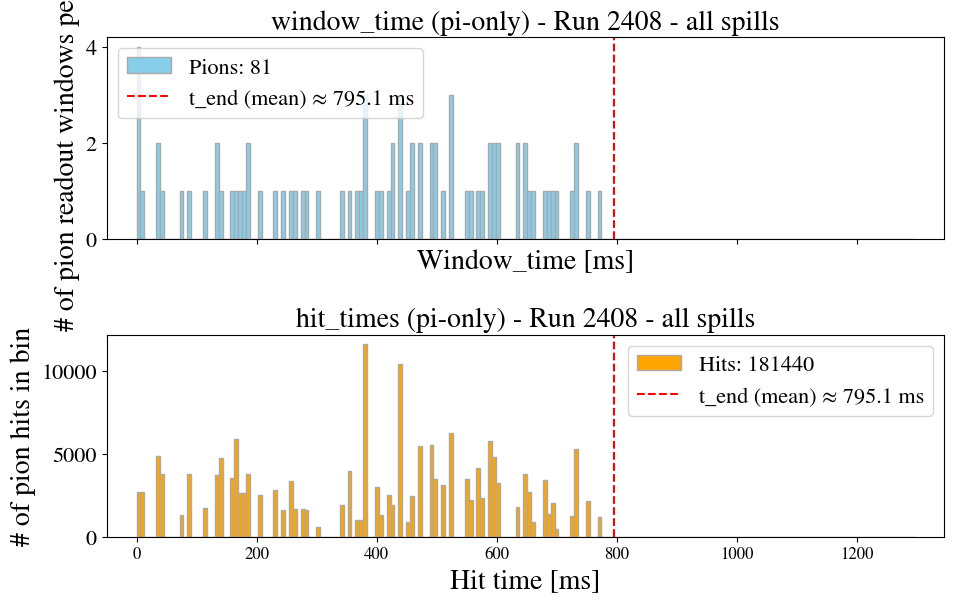

In [12]:
# ================================================================
# PION EVENTS: TIME DISTRIBUTION ALIGNED BY SPILL
# ================================================================

# Pion events after:
#   1. Quality + T0/T1/T4/T5 selection
#   2. Electron veto
#   3. Muon/pion separation

# ----------------------------------------------------------------
# Select pion events
# ----------------------------------------------------------------

pion_events = non_electron_events[pion_mask]

unique_spills_with_pions = np.unique(
    ak.to_numpy(pion_events.spill_counter)
)

if len(unique_spills_with_pions) == 0:
    raise ValueError(
        "No pions found in any spill with the current cut parameters."
    )


# ----------------------------------------------------------------
# Containers for time-aligned pion data
# ----------------------------------------------------------------

all_pion_window_times_ms = []
all_pion_hit_times_ms = []
all_t_spill_ends = []
all_t_max_spills = []


# ----------------------------------------------------------------
# Data accumulation by aligning all spills
# ----------------------------------------------------------------

for spill_id in unique_spills_with_pions:

    # ------------------------------------------------------------
    # Beam time base calibration using raw window data
    # ------------------------------------------------------------

    spill_raw_mask = arrays_windows.spill_counter == spill_id
    arrays_spill_raw = arrays_windows[spill_raw_mask]

    window_times_us_raw = (
        ak.to_numpy(arrays_spill_raw.window_time) / 1000
    )

    if len(window_times_us_raw) == 0:
        continue

    t_start_spill_us = np.min(window_times_us_raw)

    t_max_spill_ms = (
        np.max(window_times_us_raw) - t_start_spill_us
    ) / 1000

    all_t_max_spills.append(t_max_spill_ms)

    all_t_spill_ends.append(
        t_max_spill_ms - 500
    )


    # ------------------------------------------------------------
    # Extract filtered pions belonging to this spill
    # ------------------------------------------------------------

    pion_spill_mask = (
        pion_events.spill_counter == spill_id
    )

    pion_spill_events = pion_events[pion_spill_mask]

    if len(pion_spill_events) == 0:
        continue


    # ------------------------------------------------------------
    # Align pion window times relative to the spill start
    # ------------------------------------------------------------

    pion_window_times_us = (
        ak.to_numpy(pion_spill_events.window_time) / 1000
    )

    pion_window_times_rel_ms = (
        pion_window_times_us - t_start_spill_us
    ) / 1000

    all_pion_window_times_ms.extend(
        pion_window_times_rel_ms
    )


    # ------------------------------------------------------------
    # Align individual PMT hit times relative to the spill start
    # ------------------------------------------------------------

    pion_hit_times_absolute = (
        pion_spill_events.window_time[:, None]
        + pion_spill_events.hit_pmt_calibrated_times
    )

    pion_hit_times_us = (
        ak.to_numpy(
            ak.flatten(pion_hit_times_absolute)
        ) / 1000
    )

    pion_hit_times_rel_ms = (
        pion_hit_times_us - t_start_spill_us
    ) / 1000

    all_pion_hit_times_ms.extend(
        pion_hit_times_rel_ms
    )


# ----------------------------------------------------------------
# Convert accumulated lists to standard np arrays
# ----------------------------------------------------------------

all_pion_window_times_ms = np.array(
    all_pion_window_times_ms
)

all_pion_hit_times_ms = np.array(
    all_pion_hit_times_ms
)


# ----------------------------------------------------------------
# Mean beam profile statistics
# ----------------------------------------------------------------

mean_t_max_spill = np.mean(
    all_t_max_spills
)

mean_t_spill_end = np.mean(
    all_t_spill_ends
)


# ----------------------------------------------------------------
# Histogram bins
# ----------------------------------------------------------------

bins = np.linspace(
    0,
    mean_t_max_spill,
    200
)


# ----------------------------------------------------------------
# Plot
# ----------------------------------------------------------------

fig, axs = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(10, 6.5)
)


total_pions = len(
    all_pion_window_times_ms
)

total_hits = len(
    all_pion_hit_times_ms
)


# ================================================================
# TOP: PION WINDOW TIMES
# ================================================================

axs[0].hist(
    all_pion_window_times_ms,
    bins=bins,
    color="skyblue",
    edgecolor="darkgray",
    label=f"Pions: {total_pions}"
)

axs[0].axvline(
    mean_t_spill_end,
    color="red",
    linestyle="--",
    label=f"t_end (mean) ≈ {mean_t_spill_end:.1f} ms"
)

axs[0].set_ylabel(
    "# of pion readout windows per bin"
)

axs[0].set_xlabel(
    "Window_time [ms]"
)

axs[0].set_title(
    f"window_time (pi-only) - Run {run_number} - all spills"
)

axs[0].set_xlim(
    -50,
    mean_t_max_spill + 50
)

axs[0].legend(
    loc="upper left"
)


# ================================================================
# BOTTOM: PION PMT HIT TIMES
# ================================================================

axs[1].hist(
    all_pion_hit_times_ms,
    bins=bins,
    color="orange",
    edgecolor="darkgray",
    label=f"Hits: {total_hits}"
)

axs[1].axvline(
    mean_t_spill_end,
    color="red",
    linestyle="--",
    label=f"t_end (mean) ≈ {mean_t_spill_end:.1f} ms"
)

axs[1].set_xlabel(
    "Hit time [ms]"
)

axs[1].set_ylabel(
    "# of pion hits in bin"
)

axs[1].set_title(
    f"hit_times (pi-only) - Run {run_number} - all spills"
)

axs[1].legend(
    loc="upper right"
)


plt.tight_layout()
plt.show()

In [13]:
# ================================================================
# EXPECTED RADIOACTIVE ISOTOPE EVENTS
# 12B, 9Li and 16N
#
# Temporal regions:
#   Region 1: 20 - 50 ms after spill end
#   Region 2: 50 - 500 ms after spill end
#
# P(t) = exp[-(t - t_pi)/tau]
# ================================================================

TAU_12B = 30.0       # ms
TAU_9LI = 257.0      # ms
TAU_16N = 7130.0     # ms

# ------------------------------------------------
# Trigger time regions
# ------------------------------------------------

T_REGION1_START = 20.0
T_REGION1_END   = 50.0

T_REGION2_START = 50.0
T_REGION2_END   = 500.0


# ================================================================
# 1. BUILD SPILL TIMING MAP
# ================================================================

spill_timing_map = {}

unique_spills = np.unique(
    ak.to_numpy(arrays_windows.spill_counter)
)

for spill_id in unique_spills:

    spill_raw_mask = (
        arrays_windows.spill_counter == spill_id
    )

    arrays_spill_raw = arrays_windows[spill_raw_mask]

    window_times_us = (
        ak.to_numpy(arrays_spill_raw.window_time) / 1000.0
    )

    if len(window_times_us) == 0:
        continue

    # Start of the spill
    t_start_spill_us = np.min(window_times_us)

    # Maximum time covered by the readout
    t_max_spill_ms = (
        np.max(window_times_us) - t_start_spill_us
    ) / 1000.0

    # End of the beam spill
    t_end_spill_ms = t_max_spill_ms - 500.0

    spill_timing_map[spill_id] = (
        t_start_spill_us,
        t_end_spill_ms
    )


# ================================================================
# 2. BUILD ONE ROW PER PION
# ================================================================
#
# pion_events already contains only events surviving:
#
#   Quality + T0/T1/T4/T5
#   Electron veto
#   Muon/pion separation
#
# Therefore, every entry here is a selected pion event.
# ================================================================

pion_spill_ids = ak.to_numpy(
    pion_events.spill_counter
)

pion_window_times_us = (
    ak.to_numpy(pion_events.window_time) / 1000.0
)


# ------------------------------------------------
# Calculate t_pi for every pion
# ------------------------------------------------

t_pi_list = []
t_end_spill_list = []
spill_list = []

for spill_id, window_time_us in zip(
    pion_spill_ids,
    pion_window_times_us
):

    if spill_id not in spill_timing_map:
        continue

    t_start_spill_us, t_end_spill_ms = (
        spill_timing_map[spill_id]
    )

    t_pi_ms = (
        (window_time_us - t_start_spill_us)
        / 1000.0
    )

    spill_list.append(spill_id)
    t_pi_list.append(t_pi_ms)
    t_end_spill_list.append(t_end_spill_ms)


# ------------------------------------------------
# Create pion event DataFrame
# ------------------------------------------------

df_pion_events = pd.DataFrame({
    "spill_counter": spill_list,
    "t_pi [ms]": t_pi_list,
    "t_end_spill [ms]": t_end_spill_list
})


# ================================================================
# 3. CALCULATE TIME AFTER SPILL END
# ================================================================

df_pion_events["dt [ms]"] = (
    df_pion_events["t_end_spill [ms]"]
    - df_pion_events["t_pi [ms]"]
)


# ================================================================
# 4. FUNCTION FOR DECAY PROBABILITY IN A TIME INTERVAL
# ================================================================
#
# P(t1 < t < t2)
#
# = exp[-(t1 - t_pi)/tau]
# - exp[-(t2 - t_pi)/tau]
#
# Only pions entering before the beginning of the region
# can contribute.
# ================================================================

def decay_probability(
    t_pi,
    t1,
    t2,
    tau
):

    # Pions that enter after t1 cannot contribute
    if t_pi >= t1:
        return 0.0

    return (
        np.exp(-(t1 - t_pi) / tau)
        -
        np.exp(-(t2 - t_pi) / tau)
    )


# ================================================================
# 5. CALCULATE EXPECTED EVENTS FOR EACH PION
# ================================================================

# ------------------------------------------------
# REGION 1: 20 - 50 ms
# ------------------------------------------------

df_pion_events["P_12B_20_50ms"] = [
    decay_probability(
        t_pi,
        t_end + T_REGION1_START,
        t_end + T_REGION1_END,
        TAU_12B
    )
    for t_pi, t_end
    in zip(
        df_pion_events["t_pi [ms]"],
        df_pion_events["t_end_spill [ms]"]
    )
]

df_pion_events["P_9Li_20_50ms"] = [
    decay_probability(
        t_pi,
        t_end + T_REGION1_START,
        t_end + T_REGION1_END,
        TAU_9LI
    )
    for t_pi, t_end
    in zip(
        df_pion_events["t_pi [ms]"],
        df_pion_events["t_end_spill [ms]"]
    )
]

df_pion_events["P_16N_20_50ms"] = [
    decay_probability(
        t_pi,
        t_end + T_REGION1_START,
        t_end + T_REGION1_END,
        TAU_16N
    )
    for t_pi, t_end
    in zip(
        df_pion_events["t_pi [ms]"],
        df_pion_events["t_end_spill [ms]"]
    )
]


# ------------------------------------------------
# REGION 2: 50 - 500 ms
# ------------------------------------------------

df_pion_events["P_12B_50_500ms"] = [
    decay_probability(
        t_pi,
        t_end + T_REGION2_START,
        t_end + T_REGION2_END,
        TAU_12B
    )
    for t_pi, t_end
    in zip(
        df_pion_events["t_pi [ms]"],
        df_pion_events["t_end_spill [ms]"]
    )
]

df_pion_events["P_9Li_50_500ms"] = [
    decay_probability(
        t_pi,
        t_end + T_REGION2_START,
        t_end + T_REGION2_END,
        TAU_9LI
    )
    for t_pi, t_end
    in zip(
        df_pion_events["t_pi [ms]"],
        df_pion_events["t_end_spill [ms]"]
    )
]

df_pion_events["P_16N_50_500ms"] = [
    decay_probability(
        t_pi,
        t_end + T_REGION2_START,
        t_end + T_REGION2_END,
        TAU_16N
    )
    for t_pi, t_end
    in zip(
        df_pion_events["t_pi [ms]"],
        df_pion_events["t_end_spill [ms]"]
    )
]


# ================================================================
# 6. EXPECTED NUMBER OF EVENTS
# ================================================================

N_12B_region1 = df_pion_events["P_12B_20_50ms"].sum()
N_9Li_region1 = df_pion_events["P_9Li_20_50ms"].sum()
N_16N_region1 = df_pion_events["P_16N_20_50ms"].sum()

N_12B_region2 = df_pion_events["P_12B_50_500ms"].sum()
N_9Li_region2 = df_pion_events["P_9Li_50_500ms"].sum()
N_16N_region2 = df_pion_events["P_16N_50_500ms"].sum()


# ================================================================
# 7. PRINT RESULTS
# ================================================================

print("=" * 70)
print("EXPECTED RADIOACTIVE ISOTOPE EVENTS")
print("=" * 70)

print(f"Number of selected pions: {len(df_pion_events)}")
print(
    f"Number of spills containing selected pions: "
    f"{df_pion_events['spill_counter'].nunique()}"
)

print("\n--------------------------------------------------")
print("REGION 1: 20 - 50 ms after spill end")
print("--------------------------------------------------")

print(f"Expected 12B events : {N_12B_region1:.4f}")
print(f"Expected 9Li events : {N_9Li_region1:.4f}")
print(f"Expected 16N events : {N_16N_region1:.4f}")

print("\n--------------------------------------------------")
print("REGION 2: 50 - 500 ms after spill end")
print("--------------------------------------------------")

print(f"Expected 12B events : {N_12B_region2:.4f}")
print(f"Expected 9Li events : {N_9Li_region2:.4f}")
print(f"Expected 16N events : {N_16N_region2:.4f}")

print("\n--------------------------------------------------")
print("TOTAL: 20 - 500 ms")
print("--------------------------------------------------")

print(
    f"Expected 12B events : "
    f"{N_12B_region1 + N_12B_region2:.4f}"
)

print(
    f"Expected 9Li events : "
    f"{N_9Li_region1 + N_9Li_region2:.4f}"
)

print(
    f"Expected 16N events : "
    f"{N_16N_region1 + N_16N_region2:.4f}"
)

print("=" * 70)


# ================================================================
# 8. INSPECT PION-LEVEL INFORMATION
# ================================================================

df_pion_events.head(10)

EXPECTED RADIOACTIVE ISOTOPE EVENTS
Number of selected pions: 81
Number of spills containing selected pions: 72

--------------------------------------------------
REGION 1: 20 - 50 ms after spill end
--------------------------------------------------
Expected 12B events : 0.5374
Expected 9Li events : 2.4507
Expected 16N events : 0.3210

--------------------------------------------------
REGION 2: 50 - 500 ms after spill end
--------------------------------------------------
Expected 12B events : 0.3128
Expected 9Li events : 16.3566
Expected 16N events : 4.6563

--------------------------------------------------
TOTAL: 20 - 500 ms
--------------------------------------------------
Expected 12B events : 0.8502
Expected 9Li events : 18.8073
Expected 16N events : 4.9773


,spill_counter,t_pi [ms],t_end_spill [ms],dt [ms],P_12B_20_50ms,P_9Li_20_50ms,P_16N_20_50ms,P_12B_50_500ms,P_9Li_50_500ms,P_16N_50_500ms
0,2,40.101472,799.945176,759.843704,3.246430e-12,0.005300,0.003764,1.889346e-12,0.035372,0.054596
1,12,576.474672,788.045816,211.571144,2.808434e-04,0.044747,0.004065,1.634443e-04,0.298654,0.058960
2,15,382.085112,782.786776,400.701664,5.134753e-07,0.021437,0.003958,2.988306e-07,0.143075,0.057417
3,24,569.778840,792.934128,223.155288,1.908827e-04,0.042775,0.004058,1.110893e-04,0.285491,0.058864
4,26,175.915368,805.806888,629.891520,2.469770e-10,0.008787,0.003833,1.437348e-10,0.058650,0.055600
5,26,556.387904,805.806888,249.418984,7.953543e-05,0.038619,0.004043,4.628775e-05,0.257757,0.058648
6,26,729.347832,805.806888,76.459056,2.537535e-02,0.075698,0.004142,1.476786e-02,0.505230,0.060088
7,27,598.817528,781.838632,183.021104,7.273918e-04,0.050005,0.004081,4.233250e-04,0.333745,0.059197
8,34,372.383448,805.849016,433.465568,1.722715e-07,0.018871,0.003940,1.002580e-07,0.125950,0.057153
9,37,521.145880,793.224960,272.079080,3.736992e-05,0.035360,0.004030,2.174842e-05,0.236004,0.058462


In [14]:
# ================================================================
# EXPECTED 9Li EVENTS PER PION
# ================================================================
#
# N_Li9,exp = N_pi,scale * P_int * P_9Li * P(t) * epsilon
#
# For the upper-limit calculation:
#
# P_int  = 1
# P_9Li  = 1
# epsilon = 1
#
# N_pi,scale = N_pi * (N_spills_filtered / N_spills_total)
# ================================================================


# ----------------------------------------------------------------
# 1. Number of selected pions
# ----------------------------------------------------------------

N_pions = len(pion_events)


# ----------------------------------------------------------------
# 2. Number of spills
# ----------------------------------------------------------------

pion_spill_ids = ak.to_numpy(
    pion_events.spill_counter
)

unique_spills_with_pions = np.unique(
    pion_spill_ids
)

N_spills_filtered = len(
    unique_spills_with_pions
)

N_spills_total = len(
    np.unique(
        ak.to_numpy(
            arrays_windows.spill_counter
        )
    )
)


# ----------------------------------------------------------------
# 3. Scale the number of pions
# ----------------------------------------------------------------

N_pions_scale = (
    N_pions
    * N_spills_filtered
    / N_spills_total
)


# ----------------------------------------------------------------
# 4. Physics parameters
# ----------------------------------------------------------------

P_int = 1.0
P_9Li = 1.0
epsilon = 1.0

TAU_9LI = 257.0   # ms


# ----------------------------------------------------------------
# 5. Temporal regions after spill end
# ----------------------------------------------------------------

REGION_1_MIN = 20.0
REGION_1_MAX = 50.0

REGION_2_MIN = 50.0
REGION_2_MAX = 500.0


# ----------------------------------------------------------------
# 6. Build a dictionary with the end of each spill
# ----------------------------------------------------------------

spill_timing_map = {}

for spill_id in unique_spills_with_pions:

    spill_raw_mask = (
        arrays_windows.spill_counter == spill_id
    )

    arrays_spill_raw = arrays_windows[
        spill_raw_mask
    ]

    window_times_us_raw = (
        ak.to_numpy(
            arrays_spill_raw.window_time
        ) / 1000.0
    )

    if len(window_times_us_raw) == 0:
        continue

    t_start_spill_us = np.min(
        window_times_us_raw
    )

    t_max_spill_ms = (
        np.max(window_times_us_raw)
        - t_start_spill_us
    ) / 1000.0

    t_end_spill_ms = (
        t_max_spill_ms - 500.0
    )

    spill_timing_map[spill_id] = (
        t_start_spill_us,
        t_end_spill_ms
    )


# ----------------------------------------------------------------
# 7. Get t_pi and t_end for EACH pion
# ----------------------------------------------------------------
#
# We explicitly construct one t_pi and one t_end value
# for every selected pion.
#
# Therefore both arrays must have exactly N_pions entries.
# ----------------------------------------------------------------

t_pi = []
t_end_pion = []

for spill_id in unique_spills_with_pions:

    # Select pions belonging to this spill
    pion_mask_spill = (
        pion_spill_ids == spill_id
    )

    pion_spill = pion_events[
        pion_mask_spill
    ]

    if len(pion_spill) == 0:
        continue

    # Check that timing information exists
    if spill_id not in spill_timing_map:
        continue

    t_start_spill_us, t_end_spill_ms = (
        spill_timing_map[spill_id]
    )

    # Pion window times
    pion_times_us = (
        ak.to_numpy(
            pion_spill.window_time
        ) / 1000.0
    )

    pion_times_rel_ms = (
        pion_times_us
        - t_start_spill_us
    ) / 1000.0

    # One t_pi and one t_end for every pion
    t_pi.extend(
        pion_times_rel_ms
    )

    t_end_pion.extend(
        [t_end_spill_ms] * len(pion_spill)
    )


# Convert to NumPy arrays

t_pi = np.asarray(t_pi)

t_end_pion = np.asarray(t_end_pion)


# ----------------------------------------------------------------
# 8. Sanity check
# ----------------------------------------------------------------

print("================================================")
print("PION / SPILL TIMING CHECK")
print("================================================")

print(
    f"Number of selected pions:       {N_pions}"
)

print(
    f"Number of t_pi values:           {len(t_pi)}"
)

print(
    f"Number of t_end values:          {len(t_end_pion)}"
)

if not (
    len(t_pi) == len(t_end_pion) == N_pions
):
    raise ValueError(
        "Mismatch between pion times and spill-end times."
    )


# ----------------------------------------------------------------
# 9. Probability of decay inside a temporal window
# ----------------------------------------------------------------
#
# P(t) = exp[-(t - t_pi)/tau]
#
# The probability that the isotope decays between t_start
# and t_end is:
#
# P = exp[-(t_start - t_pi)/tau]
#     -
#     exp[-(t_end - t_pi)/tau]
#
# Here t_start and t_end are measured relative to the
# end of the beam spill.
# ----------------------------------------------------------------

def decay_probability(
    t_pi,
    t_spill_end,
    t_start,
    t_end,
    tau
):

    delta_start = (
        t_spill_end
        + t_start
        - t_pi
    )

    delta_end = (
        t_spill_end
        + t_end
        - t_pi
    )

    probability = (
        np.exp(-delta_start / tau)
        -
        np.exp(-delta_end / tau)
    )

    return np.where(
        delta_start >= 0,
        probability,
        0.0
    )


# ----------------------------------------------------------------
# 10. Calculate probabilities
# ----------------------------------------------------------------

P_9Li_region1 = decay_probability(
    t_pi,
    t_end_pion,
    REGION_1_MIN,
    REGION_1_MAX,
    TAU_9LI
)

P_9Li_region2 = decay_probability(
    t_pi,
    t_end_pion,
    REGION_2_MIN,
    REGION_2_MAX,
    TAU_9LI
)


# ----------------------------------------------------------------
# 11. Expected number of 9Li events
# ----------------------------------------------------------------
#
# Average probability over the selected pions, then multiply
# by the scaled pion population.
# ----------------------------------------------------------------

N_9Li_region1 = (
    N_pions_scale
    * P_int
    * P_9Li
    * np.mean(P_9Li_region1)
    * epsilon
)

N_9Li_region2 = (
    N_pions_scale
    * P_int
    * P_9Li
    * np.mean(P_9Li_region2)
    * epsilon
)

N_9Li_total = (
    N_9Li_region1
    + N_9Li_region2
)


# ----------------------------------------------------------------
# 12. Expected 9Li events PER PION
# ----------------------------------------------------------------

N_9Li_per_pion_region1 = (
    N_9Li_region1
    / N_pions_scale
)

N_9Li_per_pion_region2 = (
    N_9Li_region2
    / N_pions_scale
)

N_9Li_per_pion_total = (
    N_9Li_total
    / N_pions_scale
)


# ================================================================
# RESULTS
# ================================================================

print()
print("================================================")
print("EXPECTED 9Li EVENTS")
print("================================================")

print(
    f"Selected pions:                  {N_pions}"
)

print(
    f"Spills with selected pions:      {N_spills_filtered}"
)

print(
    f"Total spills:                    {N_spills_total}"
)

print("-----------------------------------------------")

print(
    f"N_pi,scale:                      "
    f"{N_pions_scale:.4f}"
)

print("-----------------------------------------------")

print(
    "REGION 1: 20 - 50 ms after spill end"
)

print(
    f"Expected 9Li events:              "
    f"{N_9Li_region1:.4f}"
)

print(
    f"Expected 9Li / scaled pion:       "
    f"{N_9Li_per_pion_region1:.6f}"
)

print("-----------------------------------------------")

print(
    "REGION 2: 50 - 500 ms after spill end"
)

print(
    f"Expected 9Li events:              "
    f"{N_9Li_region2:.4f}"
)

print(
    f"Expected 9Li / scaled pion:       "
    f"{N_9Li_per_pion_region2:.6f}"
)

print("-----------------------------------------------")

print(
    "TOTAL: 20 - 500 ms"
)

print(
    f"Expected 9Li events:              "
    f"{N_9Li_total:.4f}"
)

print(
    f"Expected 9Li / scaled pion:       "
    f"{N_9Li_per_pion_total:.6f}"
)

PION / SPILL TIMING CHECK
Number of selected pions:       81
Number of t_pi values:           81
Number of t_end values:          81

EXPECTED 9Li EVENTS
Selected pions:                  81
Spills with selected pions:      72
Total spills:                    475
-----------------------------------------------
N_pi,scale:                      12.2779
-----------------------------------------------
REGION 1: 20 - 50 ms after spill end
Expected 9Li events:              0.3715
Expected 9Li / scaled pion:       0.030255
-----------------------------------------------
REGION 2: 50 - 500 ms after spill end
Expected 9Li events:              2.4793
Expected 9Li / scaled pion:       0.201933
-----------------------------------------------
TOTAL: 20 - 500 ms
Expected 9Li events:              2.8508
Expected 9Li / scaled pion:       0.232189


buscar el background continuo del 16N con FV cut (high z)

In [15]:
# ================================================================
# EXPECTED RADIOACTIVE ISOTOPE PROBABILITIES PER PION
# ================================================================
#
# Isotopes:
#   12B  -> tau = 30 ms
#   9Li  -> tau = 257 ms
#   16N  -> tau = 7130 ms
#
# Temporal regions:
#   Region 1: 20 - 50 ms after spill end
#   Region 2: 50 - 500 ms after spill end
#
# P(decay in [t1,t2]) =
#
# exp[-(t0+t1-t_pi)/tau]
# -
# exp[-(t0+t2-t_pi)/tau]
#
# ================================================================


# ----------------------------------------------------------------
# Lifetimes
# ----------------------------------------------------------------

TAU_12B = 30.0       # ms
TAU_9LI = 257.0      # ms
TAU_16N = 7130.0     # ms


# ----------------------------------------------------------------
# Build the dataframe
# ----------------------------------------------------------------

df_isotope_prob = pd.DataFrame({

    "spill_counter": pion_spill_ids,

    "t_pi [ms]": t_pi,

    "t_end_spill [ms]": t_end_pion

})


# ----------------------------------------------------------------
# Time difference between pion entrance and spill end
# ----------------------------------------------------------------

df_isotope_prob["dt [ms]"] = (
    df_isotope_prob["t_end_spill [ms]"]
    - df_isotope_prob["t_pi [ms]"]
)


# ----------------------------------------------------------------
# Region 1: 20 - 50 ms
# ----------------------------------------------------------------

df_isotope_prob["P_12B_20_50ms"] = decay_probability(
    t_pi,
    t_end_pion,
    20.0,
    50.0,
    TAU_12B
)

df_isotope_prob["P_9Li_20_50ms"] = decay_probability(
    t_pi,
    t_end_pion,
    20.0,
    50.0,
    TAU_9LI
)

df_isotope_prob["P_16N_20_50ms"] = decay_probability(
    t_pi,
    t_end_pion,
    20.0,
    50.0,
    TAU_16N
)


# ----------------------------------------------------------------
# Region 2: 50 - 500 ms
# ----------------------------------------------------------------

df_isotope_prob["P_12B_50_500ms"] = decay_probability(
    t_pi,
    t_end_pion,
    50.0,
    500.0,
    TAU_12B
)

df_isotope_prob["P_9Li_50_500ms"] = decay_probability(
    t_pi,
    t_end_pion,
    50.0,
    500.0,
    TAU_9LI
)

df_isotope_prob["P_16N_50_500ms"] = decay_probability(
    t_pi,
    t_end_pion,
    50.0,
    500.0,
    TAU_16N
)


# ----------------------------------------------------------------
# Total probability: 20 - 500 ms
# ----------------------------------------------------------------

df_isotope_prob["P_12B_20_500ms"] = (
    df_isotope_prob["P_12B_20_50ms"]
    +
    df_isotope_prob["P_12B_50_500ms"]
)

df_isotope_prob["P_9Li_20_500ms"] = (
    df_isotope_prob["P_9Li_20_50ms"]
    +
    df_isotope_prob["P_9Li_50_500ms"]
)

df_isotope_prob["P_16N_20_500ms"] = (
    df_isotope_prob["P_16N_20_50ms"]
    +
    df_isotope_prob["P_16N_50_500ms"]
)


# ----------------------------------------------------------------
# Display
# ----------------------------------------------------------------

print("================================================")
print("RADIOACTIVE ISOTOPE PROBABILITIES PER PION")
print("================================================")

print(f"Number of selected pions: {len(df_isotope_prob)}")

df_isotope_prob.head(10)

RADIOACTIVE ISOTOPE PROBABILITIES PER PION
Number of selected pions: 81


,spill_counter,t_pi [ms],t_end_spill [ms],dt [ms],P_12B_20_50ms,P_9Li_20_50ms,P_16N_20_50ms,P_12B_50_500ms,P_9Li_50_500ms,P_16N_50_500ms,P_12B_20_500ms,P_9Li_20_500ms,P_16N_20_500ms
0,2,40.101472,799.945176,759.843704,3.246430e-12,0.005300,0.003764,1.889346e-12,0.035372,0.054596,5.135776e-12,0.040672,0.058360
1,12,576.474672,788.045816,211.571144,2.808434e-04,0.044747,0.004065,1.634443e-04,0.298654,0.058960,4.442877e-04,0.343401,0.063025
2,15,382.085112,782.786776,400.701664,5.134753e-07,0.021437,0.003958,2.988306e-07,0.143075,0.057417,8.123058e-07,0.164512,0.061375
3,24,569.778840,792.934128,223.155288,1.908827e-04,0.042775,0.004058,1.110893e-04,0.285491,0.058864,3.019720e-04,0.328266,0.062922
4,26,175.915368,805.806888,629.891520,2.469770e-10,0.008787,0.003833,1.437348e-10,0.058650,0.055600,3.907119e-10,0.067437,0.059433
5,26,556.387904,805.806888,249.418984,7.953543e-05,0.038619,0.004043,4.628775e-05,0.257757,0.058648,1.258232e-04,0.296377,0.062691
6,26,729.347832,805.806888,76.459056,2.537535e-02,0.075698,0.004142,1.476786e-02,0.505230,0.060088,4.014321e-02,0.580928,0.064230
7,27,598.817528,781.838632,183.021104,7.273918e-04,0.050005,0.004081,4.233250e-04,0.333745,0.059197,1.150717e-03,0.383749,0.063277
8,34,372.383448,805.849016,433.465568,1.722715e-07,0.018871,0.003940,1.002580e-07,0.125950,0.057153,2.725295e-07,0.144821,0.061093
9,37,521.145880,793.224960,272.079080,3.736992e-05,0.035360,0.004030,2.174842e-05,0.236004,0.058462,5.911833e-05,0.271364,0.062492


# Tabla bonita y para exportar a Latex

In [16]:
# ================================================================
# SUMMARY TABLE: EXPECTED EVENTS PER SPILL
# ================================================================

# ----------------------------------------------------------------
# Beam momentum
# ----------------------------------------------------------------

BEAM_P = -340       # MeV/c

# ----------------------------------------------------------------
# Number of spills and pions
# ----------------------------------------------------------------

N_spills = N_spills_filtered
N_total_pions = N_pions

# ----------------------------------------------------------------
# Region 1: 20 - 50 ms
# ----------------------------------------------------------------

events_12B_region1_per_spill = (
    N_12B_region1 / N_spills
)

events_9Li_region1_per_spill = (
    N_9Li_region1 / N_spills
)

events_16N_region1_per_spill = (
    N_16N_region1 / N_spills
)

events_total_region1_per_spill = (
    events_12B_region1_per_spill
    + events_9Li_region1_per_spill
    + events_16N_region1_per_spill
)

# ----------------------------------------------------------------
# Region 2: 50 - 500 ms
# ----------------------------------------------------------------

events_12B_region2_per_spill = (
    N_12B_region2 / N_spills
)

events_9Li_region2_per_spill = (
    N_9Li_region2 / N_spills
)

events_16N_region2_per_spill = (
    N_16N_region2 / N_spills
)

events_total_region2_per_spill = (
    events_12B_region2_per_spill
    + events_9Li_region2_per_spill
    + events_16N_region2_per_spill
)

# ----------------------------------------------------------------
# Build dataframe
# ----------------------------------------------------------------

df_expected_per_spill = pd.DataFrame({

    "Run": [run_number],

    "Beam p [MeV/c]": [BEAM_P],

    "Spills w pions": [N_spills],

    "Total pions": [N_total_pions],

    # ------------------------------------------------------------
    # Region 1: 20 - 50 ms
    # ------------------------------------------------------------

    "12B_20_50_ms": [
        events_12B_region1_per_spill
    ],

    "9Li_20_50_ms": [
        events_9Li_region1_per_spill
    ],

    "16N_20_50_ms": [
        events_16N_region1_per_spill
    ],

    "Total_20_50_ms": [
        events_total_region1_per_spill
    ],

    # ------------------------------------------------------------
    # Region 2: 50 - 500 ms
    # ------------------------------------------------------------

    "12B_50_500_ms": [
        events_12B_region2_per_spill
    ],

    "9Li_50_500_ms": [
        events_9Li_region2_per_spill
    ],

    "16N_50_500_ms": [
        events_16N_region2_per_spill
    ],

    "Total_50_500_ms": [
        events_total_region2_per_spill
    ]
})

# ================================================================
# FORMATTED DISPLAY
# ================================================================

df_expected_per_spill_display = df_expected_per_spill.copy()

# ----------------------------------------------------------------
# Format integer columns
# ----------------------------------------------------------------

for col in [
    "Run",
    "Beam p [MeV/c]",
    "Spills w pions",
    "Total pions"
]:
    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{int(x):,}")
    )

# ----------------------------------------------------------------
# Format expected events per spill
# ----------------------------------------------------------------

for col in [
    "12B_20_50_ms",
    "9Li_20_50_ms",
    "16N_20_50_ms",
    "Total_20_50_ms",
    "12B_50_500_ms",
    "9Li_50_500_ms",
    "16N_50_500_ms",
    "Total_50_500_ms"
]:
    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{x:.3f}")
    )

# ----------------------------------------------------------------
# Display
# ----------------------------------------------------------------

print("===============================================================")
print("EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL")
print("===============================================================")

display(df_expected_per_spill_display)

EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL


,Run,Beam p [MeV/c],Spills w pions,Total pions,12B_20_50_ms,9Li_20_50_ms,16N_20_50_ms,Total_20_50_ms,12B_50_500_ms,9Li_50_500_ms,16N_50_500_ms,Total_50_500_ms
0,"2,408",-340,72,81,0.007,0.005,0.004,0.017,0.004,0.034,0.065,0.103


In [17]:
# ================================================================
# EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL - ALL RUNS
# Beam momentum: -270 MeV/c
# ================================================================

import os
import re
import glob
import numpy as np
import pandas as pd
import uproot
import awkward as ak


# ================================================================
# 1. SETTINGS
# ================================================================

path = "/data/elena/data/Gd/p_270"

BEAM_P = -270       # MeV/c

TAU_12B = 30.0      # ms
TAU_9LI = 257.0     # ms
TAU_16N = 7130.0    # ms

REGION_1_MIN = 20.0
REGION_1_MAX = 50.0

REGION_2_MIN = 50.0
REGION_2_MAX = 500.0


# ================================================================
# 2. ROOT FILES
# ================================================================

root_files = sorted(
    glob.glob(
        os.path.join(
            path,
            "WCTE_merged_production_R*.root"
        )
    )
)

print(f"Found {len(root_files)} ROOT files:")
for f in root_files:
    print("  ", os.path.basename(f))


# ================================================================
# 3. BRANCHES
# ================================================================

window_branches = [

    "window_data_quality_mask",
    "vme_evt_quality_bitmask",
    "vme_digi_issues_bitmask",

    "T5_HasValidHit",
    "T5_HasMultipleScintillatorsHit",
    "T5_HasOutOfTimeWindow",
    "T5_HasInTimeWindow",
    "T5_particle_nr",

    "vme_act_eveto",
    "vme_act_tagger",

    "vme_t0_time",
    "vme_t1_time",
    "vme_t4_time",

    "window_time",
    "spill_counter",
]


scalar_branches = [
    "act_eveto_cut",
    "act_tagger_cut",
]


# ================================================================
# 4. DECAY PROBABILITY
# ================================================================

def decay_probability(
    t_pi,
    t_spill_end,
    t_start,
    t_end,
    tau
):

    delta_start = (
        t_spill_end
        + t_start
        - t_pi
    )

    delta_end = (
        t_spill_end
        + t_end
        - t_pi
    )

    probability = (
        np.exp(-delta_start / tau)
        -
        np.exp(-delta_end / tau)
    )

    return np.where(
        delta_start >= 0,
        probability,
        0.0
    )


# ================================================================
# 5. PROCESS EACH RUN
# ================================================================

results = []


for filename in root_files:

    # ------------------------------------------------------------
    # Run number
    # ------------------------------------------------------------

    match = re.search(
        r"R(\d{4})\.root",
        filename
    )

    run_number = (
        match.group(1)
        if match
        else "Unknown"
    )

    print("\n" + "=" * 70)
    print(f"Processing Run {run_number}")
    print("=" * 70)


    # ------------------------------------------------------------
    # Load ROOT trees
    # ------------------------------------------------------------

    with uproot.open(filename) as file:

        tree_windows = file["WCTEReadoutWindows"]
        tree_scalars = file["vme_analysis_scalar_results"]

        arrays_windows = tree_windows.arrays(
            window_branches,
            library="ak"
        )

        arrays_scalars = tree_scalars.arrays(
            scalar_branches,
            library="ak"
        )


    # ------------------------------------------------------------
    # PID cut values
    # ------------------------------------------------------------

    eveto_cut_value = float(
        ak.to_numpy(
            arrays_scalars["act_eveto_cut"]
        )[0]
    )

    tagger_cut_value = float(
        ak.to_numpy(
            arrays_scalars["act_tagger_cut"]
        )[0]
    )


    # ============================================================
    # EVENT QUALITY
    # ============================================================

    data_quality = (
        arrays_windows["window_data_quality_mask"] == 0
    )

    evt_quality = (
        arrays_windows["vme_evt_quality_bitmask"] == 0
    )

    digi_issues = (
        arrays_windows["vme_digi_issues_bitmask"] == 0
    )


    # ============================================================
    # T5 SELECTION
    # ============================================================

    valid_hit = (
        arrays_windows["T5_HasValidHit"] == True
    )

    mult_scint = (
        arrays_windows["T5_HasMultipleScintillatorsHit"] == False
    )

    out_of_time = (
        arrays_windows["T5_HasOutOfTimeWindow"] == False
    )

    in_time = (
        arrays_windows["T5_HasInTimeWindow"] == True
    )

    particle_nr = (
        arrays_windows["T5_particle_nr"] == 1
    )


    # ============================================================
    # T0 / T1 / T4 COINCIDENCE
    # ============================================================

    T0_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t0_time"]
        )
    )

    T1_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t1_time"]
        )
    )

    T4_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t4_time"]
        )
    )


    # ============================================================
    # FINAL QUALITY + BEAM SELECTION
    # ============================================================

    good_mask = (
        data_quality
        & evt_quality
        & digi_issues
        & valid_hit
        & mult_scint
        & out_of_time
        & in_time
        & particle_nr
        & T0_hit
        & T1_hit
        & T4_hit
    )

    filtered_windows = arrays_windows[good_mask]


    # ============================================================
    # PION PID
    # ============================================================

    mask_no_e = (
        filtered_windows["vme_act_eveto"]
        < eveto_cut_value
    )

    non_electron_events = (
        filtered_windows[mask_no_e]
    )

    pion_mask = (
        non_electron_events["vme_act_tagger"]
        < tagger_cut_value
    )

    pion_events = (
        non_electron_events[pion_mask]
    )


    # ============================================================
    # BASIC COUNTS
    # ============================================================

    N_pions = len(pion_events)

    N_spills_filtered = len(
        np.unique(
            ak.to_numpy(
                pion_events["spill_counter"]
            )
        )
    )

    N_spills_total = len(
        np.unique(
            ak.to_numpy(
                arrays_windows["spill_counter"]
            )
        )
    )


    # ------------------------------------------------------------
    # Avoid division by zero
    # ------------------------------------------------------------

    if N_pions == 0 or N_spills_filtered == 0:

        print("No selected pions. Skipping run.")

        continue


    # ============================================================
    # BUILD SPILL TIMING MAP
    # ============================================================

    spill_timing_map = {}

    unique_spills = np.unique(
        ak.to_numpy(
            arrays_windows["spill_counter"]
        )
    )

    for spill_id in unique_spills:

        spill_mask = (
            arrays_windows["spill_counter"]
            == spill_id
        )

        spill_data = arrays_windows[spill_mask]

        window_times_us = (
            ak.to_numpy(
                spill_data["window_time"]
            )
            / 1000.0
        )

        if len(window_times_us) == 0:
            continue

        t_start_spill_us = np.min(
            window_times_us
        )

        t_max_spill_ms = (
            np.max(window_times_us)
            - t_start_spill_us
        ) / 1000.0

        t_end_spill_ms = (
            t_max_spill_ms - 500.0
        )

        spill_timing_map[spill_id] = (
            t_start_spill_us,
            t_end_spill_ms
        )


    # ============================================================
    # GET t_pi AND t_end FOR EVERY PION
    # ============================================================

    pion_spill_ids = ak.to_numpy(
        pion_events["spill_counter"]
    )

    pion_window_times_us = (
        ak.to_numpy(
            pion_events["window_time"]
        )
        / 1000.0
    )

    t_pi = []
    t_end_pion = []

    for spill_id, window_time_us in zip(
        pion_spill_ids,
        pion_window_times_us
    ):

        if spill_id not in spill_timing_map:
            continue

        t_start_spill_us, t_end_spill_ms = (
            spill_timing_map[spill_id]
        )

        t_pi.append(
            (
                window_time_us
                - t_start_spill_us
            ) / 1000.0
        )

        t_end_pion.append(
            t_end_spill_ms
        )


    t_pi = np.asarray(t_pi)
    t_end_pion = np.asarray(t_end_pion)


    # ============================================================
    # CHECK
    # ============================================================

    if len(t_pi) == 0:

        print("No pion timing information. Skipping run.")

        continue


    # ============================================================
    # PROBABILITIES
    # ============================================================

    P_12B_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_12B
    )

    P_9Li_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_9LI
    )

    P_16N_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_16N
    )


    P_12B_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_12B
    )

    P_9Li_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_9LI
    )

    P_16N_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_16N
    )


    # ============================================================
    # EXPECTED EVENTS
    # ============================================================

    N_12B_region1 = np.sum(
        P_12B_region1
    )

    N_9Li_region1 = np.sum(
        P_9Li_region1
    )

    N_16N_region1 = np.sum(
        P_16N_region1
    )


    N_12B_region2 = np.sum(
        P_12B_region2
    )

    N_9Li_region2 = np.sum(
        P_9Li_region2
    )

    N_16N_region2 = np.sum(
        P_16N_region2
    )


    # ============================================================
    # EVENTS PER SPILL
    # ============================================================

    events_12B_region1_per_spill = (
        N_12B_region1
        / N_spills_filtered
    )

    events_9Li_region1_per_spill = (
        N_9Li_region1
        / N_spills_filtered
    )

    events_16N_region1_per_spill = (
        N_16N_region1
        / N_spills_filtered
    )

    events_total_region1_per_spill = (
        events_12B_region1_per_spill
        + events_9Li_region1_per_spill
        + events_16N_region1_per_spill
    )


    events_12B_region2_per_spill = (
        N_12B_region2
        / N_spills_filtered
    )

    events_9Li_region2_per_spill = (
        N_9Li_region2
        / N_spills_filtered
    )

    events_16N_region2_per_spill = (
        N_16N_region2
        / N_spills_filtered
    )

    events_total_region2_per_spill = (
        events_12B_region2_per_spill
        + events_9Li_region2_per_spill
        + events_16N_region2_per_spill
    )


    # ============================================================
    # SAVE RUN RESULT
    # ============================================================

    results.append({

        "Run": run_number,

        "Beam p [MeV/c]": BEAM_P,

        "Spills w pions": N_spills_filtered,

        "Total pions": N_pions,

        "12B_20_50_ms":
            events_12B_region1_per_spill,

        "9Li_20_50_ms":
            events_9Li_region1_per_spill,

        "16N_20_50_ms":
            events_16N_region1_per_spill,

        "Total_20_50_ms":
            events_total_region1_per_spill,

        "12B_50_500_ms":
            events_12B_region2_per_spill,

        "9Li_50_500_ms":
            events_9Li_region2_per_spill,

        "16N_50_500_ms":
            events_16N_region2_per_spill,

        "Total_50_500_ms":
            events_total_region2_per_spill
    })


    # ============================================================
    # PRINT RUN SUMMARY
    # ============================================================

    print(
        f"Pions: {N_pions:,} | "
        f"Spills: {N_spills_filtered:,} | "
        f"20-50 ms: "
        f"{events_total_region1_per_spill:.3f}/spill | "
        f"50-500 ms: "
        f"{events_total_region2_per_spill:.3f}/spill"
    )


# ================================================================
# FINAL DATAFRAME
# ================================================================

df_expected_per_spill = pd.DataFrame(
    results
)

df_expected_per_spill = (
    df_expected_per_spill
    .sort_values("Run")
    .reset_index(drop=True)
)


# ================================================================
# DISPLAY TABLE
# ================================================================

df_expected_per_spill_display = (
    df_expected_per_spill.copy()
)


# Integer columns

for col in [
    "Run",
    "Beam p [MeV/c]",
    "Spills w pions",
    "Total pions"
]:

    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{int(x)}")
    )


# Three decimal places for expected events

for col in [
    "12B_20_50_ms",
    "9Li_20_50_ms",
    "16N_20_50_ms",
    "Total_20_50_ms",
    "12B_50_500_ms",
    "9Li_50_500_ms",
    "16N_50_500_ms",
    "Total_50_500_ms"
]:

    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{x:.3f}")
    )


# ================================================================
# FINAL OUTPUT
# ================================================================

print("\n")
print("=" * 100)
print("EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL")
print("=" * 100)

display(df_expected_per_spill_display)

Found 6 ROOT files:
   WCTE_merged_production_R2407.root
   WCTE_merged_production_R2408.root
   WCTE_merged_production_R2409.root
   WCTE_merged_production_R2432.root
   WCTE_merged_production_R2434.root
   WCTE_merged_production_R2438.root

Processing Run 2407


Pions: 67 | Spills: 55 | 20-50 ms: 0.079/spill | 50-500 ms: 0.379/spill

Processing Run 2408
Pions: 81 | Spills: 72 | 20-50 ms: 0.046/spill | 50-500 ms: 0.296/spill

Processing Run 2409
Pions: 112 | Spills: 104 | 20-50 ms: 0.041/spill | 50-500 ms: 0.273/spill

Processing Run 2432
Pions: 41 | Spills: 38 | 20-50 ms: 0.065/spill | 50-500 ms: 0.370/spill

Processing Run 2434
Pions: 101 | Spills: 92 | 20-50 ms: 0.046/spill | 50-500 ms: 0.234/spill

Processing Run 2438
Pions: 137 | Spills: 117 | 20-50 ms: 0.039/spill | 50-500 ms: 0.255/spill


EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL


,Run,Beam p [MeV/c],Spills w pions,Total pions,12B_20_50_ms,9Li_20_50_ms,16N_20_50_ms,Total_20_50_ms,12B_50_500_ms,9Li_50_500_ms,16N_50_500_ms,Total_50_500_ms
0,2407,-270,55,67,0.031,0.044,0.005,0.079,0.018,0.291,0.070,0.379
1,2408,-270,72,81,0.007,0.034,0.004,0.046,0.004,0.227,0.065,0.296
2,2409,-270,104,112,0.005,0.031,0.004,0.041,0.003,0.208,0.062,0.273
3,2432,-270,38,41,0.016,0.045,0.004,0.065,0.009,0.298,0.063,0.370
4,2434,-270,92,101,0.017,0.027,0.002,0.046,0.015,0.189,0.030,0.234
5,2438,-270,117,137,0.012,0.025,0.002,0.039,0.033,0.193,0.029,0.255


In [18]:
path = "/data/elena/data/p_340"

BEAM_P = -340       # MeV/c

TAU_12B = 30.0      # ms
TAU_9LI = 257.0     # ms
TAU_16N = 7130.0    # ms

REGION_1_MIN = 20.0
REGION_1_MAX = 50.0

REGION_2_MIN = 50.0
REGION_2_MAX = 500.0


# ================================================================
# 2. ROOT FILES
# ================================================================

root_files = sorted(
    glob.glob(
        os.path.join(
            path,
            "WCTE_merged_production_R*.root"
        )
    )
)

print(f"Found {len(root_files)} ROOT files:")
for f in root_files:
    print("  ", os.path.basename(f))


# ================================================================
# 3. BRANCHES
# ================================================================

window_branches = [

    "window_data_quality_mask",
    "vme_evt_quality_bitmask",
    "vme_digi_issues_bitmask",

    "T5_HasValidHit",
    "T5_HasMultipleScintillatorsHit",
    "T5_HasOutOfTimeWindow",
    "T5_HasInTimeWindow",
    "T5_particle_nr",

    "vme_act_eveto",
    "vme_act_tagger",

    "vme_t0_time",
    "vme_t1_time",
    "vme_t4_time",

    "window_time",
    "spill_counter",
]


scalar_branches = [
    "act_eveto_cut",
    "act_tagger_cut",
]


# ================================================================
# 4. DECAY PROBABILITY
# ================================================================

def decay_probability(
    t_pi,
    t_spill_end,
    t_start,
    t_end,
    tau
):

    delta_start = (
        t_spill_end
        + t_start
        - t_pi
    )

    delta_end = (
        t_spill_end
        + t_end
        - t_pi
    )

    probability = (
        np.exp(-delta_start / tau)
        -
        np.exp(-delta_end / tau)
    )

    return np.where(
        delta_start >= 0,
        probability,
        0.0
    )


# ================================================================
# 5. PROCESS EACH RUN
# ================================================================

results = []


for filename in root_files:

    # ------------------------------------------------------------
    # Run number
    # ------------------------------------------------------------

    match = re.search(
        r"R(\d{4})\.root",
        filename
    )

    run_number = (
        match.group(1)
        if match
        else "Unknown"
    )

    print("\n" + "=" * 70)
    print(f"Processing Run {run_number}")
    print("=" * 70)


    # ------------------------------------------------------------
    # Load ROOT trees
    # ------------------------------------------------------------

    with uproot.open(filename) as file:

        tree_windows = file["WCTEReadoutWindows"]
        tree_scalars = file["vme_analysis_scalar_results"]

        arrays_windows = tree_windows.arrays(
            window_branches,
            library="ak"
        )

        arrays_scalars = tree_scalars.arrays(
            scalar_branches,
            library="ak"
        )


    # ------------------------------------------------------------
    # PID cut values
    # ------------------------------------------------------------

    eveto_cut_value = float(
        ak.to_numpy(
            arrays_scalars["act_eveto_cut"]
        )[0]
    )

    tagger_cut_value = float(
        ak.to_numpy(
            arrays_scalars["act_tagger_cut"]
        )[0]
    )


    # ============================================================
    # EVENT QUALITY
    # ============================================================

    data_quality = (
        arrays_windows["window_data_quality_mask"] == 0
    )

    evt_quality = (
        arrays_windows["vme_evt_quality_bitmask"] == 0
    )

    digi_issues = (
        arrays_windows["vme_digi_issues_bitmask"] == 0
    )


    # ============================================================
    # T5 SELECTION
    # ============================================================

    valid_hit = (
        arrays_windows["T5_HasValidHit"] == True
    )

    mult_scint = (
        arrays_windows["T5_HasMultipleScintillatorsHit"] == False
    )

    out_of_time = (
        arrays_windows["T5_HasOutOfTimeWindow"] == False
    )

    in_time = (
        arrays_windows["T5_HasInTimeWindow"] == True
    )

    particle_nr = (
        arrays_windows["T5_particle_nr"] == 1
    )


    # ============================================================
    # T0 / T1 / T4 COINCIDENCE
    # ============================================================

    T0_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t0_time"]
        )
    )

    T1_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t1_time"]
        )
    )

    T4_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t4_time"]
        )
    )


    # ============================================================
    # FINAL QUALITY + BEAM SELECTION
    # ============================================================

    good_mask = (
        data_quality
        & evt_quality
        & digi_issues
        & valid_hit
        & mult_scint
        & out_of_time
        & in_time
        & particle_nr
        & T0_hit
        & T1_hit
        & T4_hit
    )

    filtered_windows = arrays_windows[good_mask]


    # ============================================================
    # PION PID
    # ============================================================

    mask_no_e = (
        filtered_windows["vme_act_eveto"]
        < eveto_cut_value
    )

    non_electron_events = (
        filtered_windows[mask_no_e]
    )

    pion_mask = (
        non_electron_events["vme_act_tagger"]
        < tagger_cut_value
    )

    pion_events = (
        non_electron_events[pion_mask]
    )


    # ============================================================
    # BASIC COUNTS
    # ============================================================

    N_pions = len(pion_events)

    N_spills_filtered = len(
        np.unique(
            ak.to_numpy(
                pion_events["spill_counter"]
            )
        )
    )

    N_spills_total = len(
        np.unique(
            ak.to_numpy(
                arrays_windows["spill_counter"]
            )
        )
    )


    # ------------------------------------------------------------
    # Avoid division by zero
    # ------------------------------------------------------------

    if N_pions == 0 or N_spills_filtered == 0:

        print("No selected pions. Skipping run.")

        continue


    # ============================================================
    # BUILD SPILL TIMING MAP
    # ============================================================

    spill_timing_map = {}

    unique_spills = np.unique(
        ak.to_numpy(
            arrays_windows["spill_counter"]
        )
    )

    for spill_id in unique_spills:

        spill_mask = (
            arrays_windows["spill_counter"]
            == spill_id
        )

        spill_data = arrays_windows[spill_mask]

        window_times_us = (
            ak.to_numpy(
                spill_data["window_time"]
            )
            / 1000.0
        )

        if len(window_times_us) == 0:
            continue

        t_start_spill_us = np.min(
            window_times_us
        )

        t_max_spill_ms = (
            np.max(window_times_us)
            - t_start_spill_us
        ) / 1000.0

        t_end_spill_ms = (
            t_max_spill_ms - 500.0
        )

        spill_timing_map[spill_id] = (
            t_start_spill_us,
            t_end_spill_ms
        )


    # ============================================================
    # GET t_pi AND t_end FOR EVERY PION
    # ============================================================

    pion_spill_ids = ak.to_numpy(
        pion_events["spill_counter"]
    )

    pion_window_times_us = (
        ak.to_numpy(
            pion_events["window_time"]
        )
        / 1000.0
    )

    t_pi = []
    t_end_pion = []

    for spill_id, window_time_us in zip(
        pion_spill_ids,
        pion_window_times_us
    ):

        if spill_id not in spill_timing_map:
            continue

        t_start_spill_us, t_end_spill_ms = (
            spill_timing_map[spill_id]
        )

        t_pi.append(
            (
                window_time_us
                - t_start_spill_us
            ) / 1000.0
        )

        t_end_pion.append(
            t_end_spill_ms
        )


    t_pi = np.asarray(t_pi)
    t_end_pion = np.asarray(t_end_pion)


    # ============================================================
    # CHECK
    # ============================================================

    if len(t_pi) == 0:

        print("No pion timing information. Skipping run.")

        continue


    # ============================================================
    # PROBABILITIES
    # ============================================================

    P_12B_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_12B
    )

    P_9Li_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_9LI
    )

    P_16N_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_16N
    )


    P_12B_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_12B
    )

    P_9Li_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_9LI
    )

    P_16N_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_16N
    )


    # ============================================================
    # EXPECTED EVENTS
    # ============================================================

    N_12B_region1 = np.sum(
        P_12B_region1
    )

    N_9Li_region1 = np.sum(
        P_9Li_region1
    )

    N_16N_region1 = np.sum(
        P_16N_region1
    )


    N_12B_region2 = np.sum(
        P_12B_region2
    )

    N_9Li_region2 = np.sum(
        P_9Li_region2
    )

    N_16N_region2 = np.sum(
        P_16N_region2
    )


    # ============================================================
    # EVENTS PER SPILL
    # ============================================================

    events_12B_region1_per_spill = (
        N_12B_region1
        / N_spills_filtered
    )

    events_9Li_region1_per_spill = (
        N_9Li_region1
        / N_spills_filtered
    )

    events_16N_region1_per_spill = (
        N_16N_region1
        / N_spills_filtered
    )

    events_total_region1_per_spill = (
        events_12B_region1_per_spill
        + events_9Li_region1_per_spill
        + events_16N_region1_per_spill
    )


    events_12B_region2_per_spill = (
        N_12B_region2
        / N_spills_filtered
    )

    events_9Li_region2_per_spill = (
        N_9Li_region2
        / N_spills_filtered
    )

    events_16N_region2_per_spill = (
        N_16N_region2
        / N_spills_filtered
    )

    events_total_region2_per_spill = (
        events_12B_region2_per_spill
        + events_9Li_region2_per_spill
        + events_16N_region2_per_spill
    )


    # ============================================================
    # SAVE RUN RESULT
    # ============================================================

    results.append({

        "Run": run_number,

        "Beam p [MeV/c]": BEAM_P,

        "Spills w pions": N_spills_filtered,

        "Total pions": N_pions,

        "12B_20_50_ms":
            events_12B_region1_per_spill,

        "9Li_20_50_ms":
            events_9Li_region1_per_spill,

        "16N_20_50_ms":
            events_16N_region1_per_spill,

        "Total_20_50_ms":
            events_total_region1_per_spill,

        "12B_50_500_ms":
            events_12B_region2_per_spill,

        "9Li_50_500_ms":
            events_9Li_region2_per_spill,

        "16N_50_500_ms":
            events_16N_region2_per_spill,

        "Total_50_500_ms":
            events_total_region2_per_spill
    })


    # ============================================================
    # PRINT RUN SUMMARY
    # ============================================================

    print(
        f"Pions: {N_pions:,} | "
        f"Spills: {N_spills_filtered:,} | "
        f"20-50 ms: "
        f"{events_total_region1_per_spill:.3f}/spill | "
        f"50-500 ms: "
        f"{events_total_region2_per_spill:.3f}/spill"
    )


# ================================================================
# FINAL DATAFRAME
# ================================================================

df_expected_per_spill = pd.DataFrame(
    results
)

df_expected_per_spill = (
    df_expected_per_spill
    .sort_values("Run")
    .reset_index(drop=True)
)


# ================================================================
# DISPLAY TABLE
# ================================================================

df_expected_per_spill_display = (
    df_expected_per_spill.copy()
)


# Integer columns

for col in [
    "Run",
    "Beam p [MeV/c]",
    "Spills w pions",
    "Total pions"
]:

    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{int(x)}")
    )


# Three decimal places for expected events

for col in [
    "12B_20_50_ms",
    "9Li_20_50_ms",
    "16N_20_50_ms",
    "Total_20_50_ms",
    "12B_50_500_ms",
    "9Li_50_500_ms",
    "16N_50_500_ms",
    "Total_50_500_ms"
]:

    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{x:.3f}")
    )


# ================================================================
# FINAL OUTPUT
# ================================================================

print("\n")
print("=" * 100)
print("EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL")
print("=" * 100)

display(df_expected_per_spill_display)

Found 2 ROOT files:
   WCTE_merged_production_R1846.root
   WCTE_merged_production_R1848.root

Processing Run 1846
Pions: 258 | Spills: 165 | 20-50 ms: 0.095/spill | 50-500 ms: 0.490/spill

Processing Run 1848
Pions: 254 | Spills: 162 | 20-50 ms: 0.088/spill | 50-500 ms: 0.460/spill


EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL


,Run,Beam p [MeV/c],Spills w pions,Total pions,12B_20_50_ms,9Li_20_50_ms,16N_20_50_ms,Total_20_50_ms,12B_50_500_ms,9Li_50_500_ms,16N_50_500_ms,Total_50_500_ms
0,1846,-340,165,258,0.031,0.057,0.006,0.095,0.018,0.382,0.090,0.490
1,1848,-340,162,254,0.028,0.053,0.006,0.088,0.017,0.354,0.090,0.460


In [19]:

path = "/data/elena/data/p_260"

BEAM_P = -260       # MeV/c

TAU_12B = 30.0      # ms
TAU_9LI = 257.0     # ms
TAU_16N = 7130.0    # ms

REGION_1_MIN = 20.0
REGION_1_MAX = 50.0

REGION_2_MIN = 50.0
REGION_2_MAX = 500.0


# ================================================================
# 2. ROOT FILES
# ================================================================

root_files = sorted(
    glob.glob(
        os.path.join(
            path,
            "WCTE_merged_production_R*.root"
        )
    )
)

print(f"Found {len(root_files)} ROOT files:")
for f in root_files:
    print("  ", os.path.basename(f))


# ================================================================
# 3. BRANCHES
# ================================================================

window_branches = [

    "window_data_quality_mask",
    "vme_evt_quality_bitmask",
    "vme_digi_issues_bitmask",

    "T5_HasValidHit",
    "T5_HasMultipleScintillatorsHit",
    "T5_HasOutOfTimeWindow",
    "T5_HasInTimeWindow",
    "T5_particle_nr",

    "vme_act_eveto",
    "vme_act_tagger",

    "vme_t0_time",
    "vme_t1_time",
    "vme_t4_time",

    "window_time",
    "spill_counter",
]


scalar_branches = [
    "act_eveto_cut",
    "act_tagger_cut",
]


# ================================================================
# 4. DECAY PROBABILITY
# ================================================================

def decay_probability(
    t_pi,
    t_spill_end,
    t_start,
    t_end,
    tau
):

    delta_start = (
        t_spill_end
        + t_start
        - t_pi
    )

    delta_end = (
        t_spill_end
        + t_end
        - t_pi
    )

    probability = (
        np.exp(-delta_start / tau)
        -
        np.exp(-delta_end / tau)
    )

    return np.where(
        delta_start >= 0,
        probability,
        0.0
    )


# ================================================================
# 5. PROCESS EACH RUN
# ================================================================

results = []


for filename in root_files:

    # ------------------------------------------------------------
    # Run number
    # ------------------------------------------------------------

    match = re.search(
        r"R(\d{4})\.root",
        filename
    )

    run_number = (
        match.group(1)
        if match
        else "Unknown"
    )

    print("\n" + "=" * 70)
    print(f"Processing Run {run_number}")
    print("=" * 70)


    # ------------------------------------------------------------
    # Load ROOT trees
    # ------------------------------------------------------------

    with uproot.open(filename) as file:

        tree_windows = file["WCTEReadoutWindows"]
        tree_scalars = file["vme_analysis_scalar_results"]

        arrays_windows = tree_windows.arrays(
            window_branches,
            library="ak"
        )

        arrays_scalars = tree_scalars.arrays(
            scalar_branches,
            library="ak"
        )


    # ------------------------------------------------------------
    # PID cut values
    # ------------------------------------------------------------

    eveto_cut_value = float(
        ak.to_numpy(
            arrays_scalars["act_eveto_cut"]
        )[0]
    )

    tagger_cut_value = float(
        ak.to_numpy(
            arrays_scalars["act_tagger_cut"]
        )[0]
    )


    # ============================================================
    # EVENT QUALITY
    # ============================================================

    data_quality = (
        arrays_windows["window_data_quality_mask"] == 0
    )

    evt_quality = (
        arrays_windows["vme_evt_quality_bitmask"] == 0
    )

    digi_issues = (
        arrays_windows["vme_digi_issues_bitmask"] == 0
    )


    # ============================================================
    # T5 SELECTION
    # ============================================================

    valid_hit = (
        arrays_windows["T5_HasValidHit"] == True
    )

    mult_scint = (
        arrays_windows["T5_HasMultipleScintillatorsHit"] == False
    )

    out_of_time = (
        arrays_windows["T5_HasOutOfTimeWindow"] == False
    )

    in_time = (
        arrays_windows["T5_HasInTimeWindow"] == True
    )

    particle_nr = (
        arrays_windows["T5_particle_nr"] == 1
    )


    # ============================================================
    # T0 / T1 / T4 COINCIDENCE
    # ============================================================

    T0_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t0_time"]
        )
    )

    T1_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t1_time"]
        )
    )

    T4_hit = ~np.isnan(
        ak.to_numpy(
            arrays_windows["vme_t4_time"]
        )
    )


    # ============================================================
    # FINAL QUALITY + BEAM SELECTION
    # ============================================================

    good_mask = (
        data_quality
        & evt_quality
        & digi_issues
        & valid_hit
        & mult_scint
        & out_of_time
        & in_time
        & particle_nr
        & T0_hit
        & T1_hit
        & T4_hit
    )

    filtered_windows = arrays_windows[good_mask]


    # ============================================================
    # PION PID
    # ============================================================

    mask_no_e = (
        filtered_windows["vme_act_eveto"]
        < eveto_cut_value
    )

    non_electron_events = (
        filtered_windows[mask_no_e]
    )

    pion_mask = (
        non_electron_events["vme_act_tagger"]
        < tagger_cut_value
    )

    pion_events = (
        non_electron_events[pion_mask]
    )


    # ============================================================
    # BASIC COUNTS
    # ============================================================

    N_pions = len(pion_events)

    N_spills_filtered = len(
        np.unique(
            ak.to_numpy(
                pion_events["spill_counter"]
            )
        )
    )

    N_spills_total = len(
        np.unique(
            ak.to_numpy(
                arrays_windows["spill_counter"]
            )
        )
    )


    # ------------------------------------------------------------
    # Avoid division by zero
    # ------------------------------------------------------------

    if N_pions == 0 or N_spills_filtered == 0:

        print("No selected pions. Skipping run.")

        continue


    # ============================================================
    # BUILD SPILL TIMING MAP
    # ============================================================

    spill_timing_map = {}

    unique_spills = np.unique(
        ak.to_numpy(
            arrays_windows["spill_counter"]
        )
    )

    for spill_id in unique_spills:

        spill_mask = (
            arrays_windows["spill_counter"]
            == spill_id
        )

        spill_data = arrays_windows[spill_mask]

        window_times_us = (
            ak.to_numpy(
                spill_data["window_time"]
            )
            / 1000.0
        )

        if len(window_times_us) == 0:
            continue

        t_start_spill_us = np.min(
            window_times_us
        )

        t_max_spill_ms = (
            np.max(window_times_us)
            - t_start_spill_us
        ) / 1000.0

        t_end_spill_ms = (
            t_max_spill_ms - 500.0
        )

        spill_timing_map[spill_id] = (
            t_start_spill_us,
            t_end_spill_ms
        )


    # ============================================================
    # GET t_pi AND t_end FOR EVERY PION
    # ============================================================

    pion_spill_ids = ak.to_numpy(
        pion_events["spill_counter"]
    )

    pion_window_times_us = (
        ak.to_numpy(
            pion_events["window_time"]
        )
        / 1000.0
    )

    t_pi = []
    t_end_pion = []

    for spill_id, window_time_us in zip(
        pion_spill_ids,
        pion_window_times_us
    ):

        if spill_id not in spill_timing_map:
            continue

        t_start_spill_us, t_end_spill_ms = (
            spill_timing_map[spill_id]
        )

        t_pi.append(
            (
                window_time_us
                - t_start_spill_us
            ) / 1000.0
        )

        t_end_pion.append(
            t_end_spill_ms
        )


    t_pi = np.asarray(t_pi)
    t_end_pion = np.asarray(t_end_pion)


    # ============================================================
    # CHECK
    # ============================================================

    if len(t_pi) == 0:

        print("No pion timing information. Skipping run.")

        continue


    # ============================================================
    # PROBABILITIES
    # ============================================================

    P_12B_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_12B
    )

    P_9Li_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_9LI
    )

    P_16N_region1 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_1_MIN,
        REGION_1_MAX,
        TAU_16N
    )


    P_12B_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_12B
    )

    P_9Li_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_9LI
    )

    P_16N_region2 = decay_probability(
        t_pi,
        t_end_pion,
        REGION_2_MIN,
        REGION_2_MAX,
        TAU_16N
    )


    # ============================================================
    # EXPECTED EVENTS
    # ============================================================

    N_12B_region1 = np.sum(
        P_12B_region1
    )

    N_9Li_region1 = np.sum(
        P_9Li_region1
    )

    N_16N_region1 = np.sum(
        P_16N_region1
    )


    N_12B_region2 = np.sum(
        P_12B_region2
    )

    N_9Li_region2 = np.sum(
        P_9Li_region2
    )

    N_16N_region2 = np.sum(
        P_16N_region2
    )


    # ============================================================
    # EVENTS PER SPILL
    # ============================================================

    events_12B_region1_per_spill = (
        N_12B_region1
        / N_spills_filtered
    )

    events_9Li_region1_per_spill = (
        N_9Li_region1
        / N_spills_filtered
    )

    events_16N_region1_per_spill = (
        N_16N_region1
        / N_spills_filtered
    )

    events_total_region1_per_spill = (
        events_12B_region1_per_spill
        + events_9Li_region1_per_spill
        + events_16N_region1_per_spill
    )


    events_12B_region2_per_spill = (
        N_12B_region2
        / N_spills_filtered
    )

    events_9Li_region2_per_spill = (
        N_9Li_region2
        / N_spills_filtered
    )

    events_16N_region2_per_spill = (
        N_16N_region2
        / N_spills_filtered
    )

    events_total_region2_per_spill = (
        events_12B_region2_per_spill
        + events_9Li_region2_per_spill
        + events_16N_region2_per_spill
    )


    # ============================================================
    # SAVE RUN RESULT
    # ============================================================

    results.append({

        "Run": run_number,

        "Beam p [MeV/c]": BEAM_P,

        "Spills w pions": N_spills_filtered,

        "Total pions": N_pions,

        "12B_20_50_ms":
            events_12B_region1_per_spill,

        "9Li_20_50_ms":
            events_9Li_region1_per_spill,

        "16N_20_50_ms":
            events_16N_region1_per_spill,

        "Total_20_50_ms":
            events_total_region1_per_spill,

        "12B_50_500_ms":
            events_12B_region2_per_spill,

        "9Li_50_500_ms":
            events_9Li_region2_per_spill,

        "16N_50_500_ms":
            events_16N_region2_per_spill,

        "Total_50_500_ms":
            events_total_region2_per_spill
    })


    # ============================================================
    # PRINT RUN SUMMARY
    # ============================================================

    print(
        f"Pions: {N_pions:,} | "
        f"Spills: {N_spills_filtered:,} | "
        f"20-50 ms: "
        f"{events_total_region1_per_spill:.3f}/spill | "
        f"50-500 ms: "
        f"{events_total_region2_per_spill:.3f}/spill"
    )


# ================================================================
# FINAL DATAFRAME
# ================================================================

df_expected_per_spill = pd.DataFrame(
    results
)

df_expected_per_spill = (
    df_expected_per_spill
    .sort_values("Run")
    .reset_index(drop=True)
)


# ================================================================
# DISPLAY TABLE
# ================================================================

df_expected_per_spill_display = (
    df_expected_per_spill.copy()
)


# Integer columns

for col in [
    "Run",
    "Beam p [MeV/c]",
    "Spills w pions",
    "Total pions"
]:

    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{int(x)}")
    )


# Three decimal places for expected events

for col in [
    "12B_20_50_ms",
    "9Li_20_50_ms",
    "16N_20_50_ms",
    "Total_20_50_ms",
    "12B_50_500_ms",
    "9Li_50_500_ms",
    "16N_50_500_ms",
    "Total_50_500_ms"
]:

    df_expected_per_spill_display[col] = (
        df_expected_per_spill_display[col]
        .map(lambda x: f"{x:.3f}")
    )


# ================================================================
# FINAL OUTPUT
# ================================================================

print("\n")
print("=" * 100)
print("EXPECTED RADIOACTIVE ISOTOPE EVENTS PER SPILL")
print("=" * 100)

display(df_expected_per_spill_display)

Found 10 ROOT files:
   WCTE_merged_production_R1928.root
   WCTE_merged_production_R1930.root
   WCTE_merged_production_R1932.root
   WCTE_merged_production_R1934.root
   WCTE_merged_production_R1935.root
   WCTE_merged_production_R1936.root
   WCTE_merged_production_R1937.root
   WCTE_merged_production_R1938.root
   WCTE_merged_production_R1939.root
   WCTE_merged_production_R1941.root

Processing Run 1928
Pions: 153 | Spills: 129 | 20-50 ms: 0.042/spill | 50-500 ms: 0.283/spill

Processing Run 1930
Pions: 79 | Spills: 67 | 20-50 ms: 0.050/spill | 50-500 ms: 0.324/spill

Processing Run 1932
Pions: 225 | Spills: 182 | 20-50 ms: 0.052/spill | 50-500 ms: 0.316/spill

Processing Run 1934
Pions: 120 | Spills: 102 | 20-50 ms: 0.047/spill | 50-500 ms: 0.297/spill

Processing Run 1935
Pions: 138 | Spills: 115 | 20-50 ms: 0.054/spill | 50-500 ms: 0.325/spill

Processing Run 1936
Pions: 123 | Spills: 104 | 20-50 ms: 0.034/spill | 50-500 ms: 0.251/spill

Processing Run 1937
Pions: 184 | Spills:

,Run,Beam p [MeV/c],Spills w pions,Total pions,12B_20_50_ms,9Li_20_50_ms,16N_20_50_ms,Total_20_50_ms,12B_50_500_ms,9Li_50_500_ms,16N_50_500_ms,Total_50_500_ms
0,1928,-260,129,153,0.006,0.032,0.005,0.042,0.003,0.212,0.067,0.283
1,1930,-260,67,79,0.007,0.038,0.005,0.050,0.004,0.252,0.068,0.324
2,1932,-260,182,225,0.011,0.036,0.005,0.052,0.006,0.239,0.071,0.316
3,1934,-260,102,120,0.009,0.034,0.005,0.047,0.005,0.225,0.067,0.297
4,1935,-260,115,138,0.012,0.037,0.005,0.054,0.007,0.249,0.069,0.325
5,1936,-260,104,123,0.001,0.027,0.005,0.034,0.001,0.183,0.067,0.251
6,1937,-260,146,184,0.012,0.036,0.005,0.053,0.007,0.244,0.072,0.323
7,1938,-260,69,83,0.006,0.028,0.005,0.039,0.004,0.188,0.068,0.261
8,1939,-260,110,136,0.008,0.038,0.005,0.051,0.005,0.251,0.071,0.327
9,1941,-260,162,195,0.008,0.031,0.005,0.044,0.005,0.209,0.069,0.282
